## 1. Problem Understanding

### Problem Definition

NetGuard is a network intrusion detection system that uses machine learning to classify network-flow records as either normal traffic or attack traffic.

This is a binary classification problem.

### Observation

Each observation represents a network-flow/connection record containing characteristics such as connection duration, protocol, service, packet counts, byte counts, TCP information, and connection-level statistics.

### Target Variable

The target variable is `label`:

- `0` → Normal traffic
- `1` → Attack traffic

### Candidate Input Features

The dataset contains network-flow characteristics that may be used as predictors, including numerical and categorical features.

The final feature set will not be determined at this stage. EDA will be used to identify problematic, redundant, or potentially leaking features before model training.

### Error Considerations

Two important classification errors are:

- **False Positive:** Normal traffic incorrectly classified as an attack.
- **False Negative:** Attack traffic incorrectly classified as normal.

For an intrusion detection system, false negatives are particularly important because they represent attacks that the system failed to detect.

### Evaluation Considerations

Because the cost of false negatives and false positives differs, model evaluation should not rely on accuracy alone.

We will later consider:

- Precision
- Attack Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix
- Prediction threshold

### EDA Objective

The purpose of EDA is to understand the network-flow data, identify data-quality problems, understand differences between normal and attack traffic, detect potential leakage and distribution differences, and generate evidence-based hypotheses for feature engineering and model development.

## 2. Dataset Structure & Schema Audit

### Objective

The objective of this section is to understand the structure and semantics of the UNSW-NB15 dataset before performing statistical analysis or visualization.

We will investigate:

- Dataset dimensions
- Column names and data types
- Number of unique values
- Numerical and categorical variables
- Binary and identifier-like variables
- Target-related columns
- Potential leakage candidates

This step is important because the data type reported by Pandas does not necessarily represent the semantic role of a feature. For example, an integer column may represent an identifier or binary indicator rather than a continuous numerical variable.

No feature will be removed at this stage solely based on its data type or cardinality. Any feature-removal decision will require further investigation and evidence.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
train_df = pd.read_csv("../data/raw/UNSW_NB15_testing-set.csv")   # 175,341 rows
test_df = pd.read_csv("../data/raw/UNSW_NB15_training-set.csv")   # a82,332 rows



In [14]:
schema = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.astype(str),
    "unique_values": train_df.nunique(),
    "missing_values": train_df.isna().sum(),
    "missing_%": (train_df.isna().mean() * 100).round(2)
})

display(schema)

,column,dtype,unique_values,missing_values,missing_%
id,id,int64,175341,0,0.0
dur,dur,float64,74039,0,0.0
proto,proto,str,133,0,0.0
service,service,str,13,0,0.0
state,state,str,9,0,0.0
spkts,spkts,int64,480,0,0.0
dpkts,dpkts,int64,443,0,0.0
sbytes,sbytes,int64,7214,0,0.0
dbytes,dbytes,int64,6660,0,0.0
rate,rate,float64,76991,0,0.0


### Schema Findings

The training dataset contains **175,341 observations and 45 columns**. All columns contain zero missing values according to the initial schema audit.

The columns have different semantic roles and therefore cannot be classified purely based on their Pandas data types.

Initial observations:

- `id` contains **175,341 unique values**, equal to the number of training observations. It appears to be an identifier and requires further investigation before deciding whether it should be excluded.
- `proto`, `service`, and `state` are categorical network attributes with 133, 13, and 9 unique values respectively.
- `label` contains two unique values and represents the binary classification target.
- `attack_cat` contains 10 categories and requires separate investigation because it may contain information directly related to the target.
- Several integer-valued features have relatively low cardinality, but their semantic meaning indicates that they are network measurements or counts rather than necessarily categorical variables.
- No missing values were identified in the training dataset at this stage.

### Important Observation

The dataset contains different types of variables including identifiers, categorical variables, binary indicators, counts, continuous measurements, and target-related information.

Therefore, feature classification will be based on **feature semantics rather than only Pandas data types or number of unique values**.

No features are removed at this stage. Further EDA will be used to investigate their distributions, relationships, redundancy, and potential leakage.

### Feature Dictionary

| Column | Meaning |
|---|---|
| `id` | Unique flow identifier |
| `dur` | Connection duration |
| `proto` | Network protocol |
| `service` | Network service |
| `state` | Connection state |
| `spkts`, `dpkts` | Source/destination packet counts |
| `sbytes`, `dbytes` | Source/destination byte counts |
| `rate` | Traffic rate |
| `sttl`, `dttl` | Source/destination TTL |
| `sload`, `dload` | Source/destination traffic load |
| `sloss`, `dloss` | Source/destination packet loss |
| `sinpkt`, `dinpkt` | Source/destination inter-packet time |
| `sjit`, `djit` | Source/destination packet jitter |
| `swin`, `dwin` | Source/destination TCP window size |
| `stcpb`, `dtcpb` | Source/destination TCP base sequence numbers |
| `tcprtt` | TCP round-trip time |
| `synack` | SYN to SYN-ACK time |
| `ackdat` | SYN-ACK to ACK time |
| `smean`, `dmean` | Mean source/destination packet size |
| `trans_depth` | Transaction depth |
| `response_body_len` | Response body size |
| `ct_*` | Connection-count/context features |
| `is_ftp_login` | FTP login indicator |
| `ct_ftp_cmd` | FTP command count |
| `ct_flw_http_mthd` | HTTP method count |
| `is_sm_ips_ports` | Source/destination IP-port relationship indicator |
| `attack_cat` | Attack category |
| `label` | Target: `0` = Normal, `1` = Attack |

id – Unique identifier for each network flow.

dur – Duration of the network connection.

proto – Network communication protocol used, such as TCP or UDP.

service – Network service associated with the flow, such as HTTP, DNS, or FTP.

state – State/status of the network connection.

spkts, dpkts – Number of packets sent from the source and destination.

sbytes, dbytes – Number of bytes sent from the source and destination.

rate – Rate of data transmission in the flow.

sttl, dttl – Time-to-Live (TTL) values for source and destination traffic.

sload, dload – Data transmission load/rate from source and destination.

sloss, dloss – Number of packets lost from source and destination.

sinpkt, dinpkt – Average time between packets for source and destination traffic.

sjit, djit – Variation (jitter) in packet arrival times for source and destination.

swin, dwin – TCP window sizes for source and destination.

stcpb, dtcpb – TCP base sequence numbers for source and destination.

tcprtt – TCP round-trip time.

synack – Time between SYN and SYN-ACK during TCP connection establishment.

ackdat – Time between SYN-ACK and the corresponding ACK.

smean, dmean – Mean packet size for source and destination traffic.

trans_depth – Depth of the transaction within the connection.

response_body_len – Size of the response body returned by the server.

ct_* – Connection/context statistics describing how frequently related connections, services, ports, or states occur.

is_ftp_login – Indicates whether an FTP login was detected.

ct_ftp_cmd – Number of FTP commands observed.

ct_flw_http_mthd – Number of HTTP methods observed in related flows.

is_sm_ips_ports – Indicates whether the source and destination IP/port relationship matches a specific pattern.

attack_cat – Attack category, such as DoS, Exploits, Fuzzers, or Normal.

label – Target variable: 0 represents normal traffic and 1 represents attack traffic.

In [15]:
low_cardinality_cols = [
    col for col in train_df.columns
    if train_df[col].nunique() <= 15
]

for col in low_cardinality_cols:
    print(f"\n===== {col} =====")
    print(train_df[col].value_counts(dropna=False))


===== service =====
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

===== state =====
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

===== sttl =====
sttl
254    114743
31      39455
62      17681
0        3162
64        181
1          64
63         32
255        13
60          6
252         2
29          2
Name: count, dtype: int64

===== dttl =====
dttl
0      84372
252    50643
29     39455
60       867
254        2
31         2
Name: count, dtype: int64

===== swin =====
swin
0      95395
255    79935
31         1
232        1
14         1
192        1
103        1
45         1
87         1
172        1
168        1
167        1
42         1
Name: count, dtype: i

### Low-Cardinality Feature Findings

- `service` contains a small number of categories, with the `-` category representing a large proportion of observations.
- `state` is dominated by a small number of connection states, particularly `INT` and `FIN`.
- `label` contains two classes, with attack traffic occurring more frequently than normal traffic.
- The observed class and category distributions will be investigated further in the appropriate EDA sections.
- No features are removed based on these distributions at this stage.

In [16]:
for col in low_cardinality_cols:
    print(
        f"{col:20} | "
        f"unique={train_df[col].nunique():3} | "
        f"top={train_df[col].value_counts().index[0]} | "
        f"top_count={train_df[col].value_counts().iloc[0]}"
    )
    

service              | unique= 13 | top=- | top_count=94168
state                | unique=  9 | top=INT | top_count=82275
sttl                 | unique= 11 | top=254 | top_count=114743
dttl                 | unique=  6 | top=0 | top_count=84372
swin                 | unique= 13 | top=0 | top_count=95395
dwin                 | unique=  7 | top=0 | top_count=96253
trans_depth          | unique= 11 | top=0 | top_count=157501
ct_state_ttl         | unique=  5 | top=2 | top_count=82054
is_ftp_login         | unique=  4 | top=0 | top_count=172774
ct_ftp_cmd           | unique=  4 | top=0 | top_count=172774
ct_flw_http_mthd     | unique= 11 | top=0 | top_count=157501
is_sm_ips_ports      | unique=  2 | top=0 | top_count=172579
attack_cat           | unique= 10 | top=Normal | top_count=56000
label                | unique=  2 | top=1 | top_count=119341


### Low-Cardinality Findings

Several features have relatively few unique values and highly concentrated distributions.

- `service` and `state` are categorical features with dominant categories.
- `sttl`, `dttl`, `swin`, and `dwin` are discrete network/TCP measurements rather than automatically categorical variables.
- `trans_depth`, `ct_flw_http_mthd`, `is_ftp_login`, and `ct_ftp_cmd` contain a large proportion of zero values.
- `is_sm_ips_ports` is a binary feature.
- `attack_cat` contains attack-category information and requires leakage investigation.
- `label` is imbalanced toward the attack class.

These observations identify features that require further investigation, but no feature is removed at this stage.

In [17]:
print("Train ID unique:", train_df["id"].nunique())
print("Train rows:", len(train_df))

print("\nTrain ID range:")
print(train_df["id"].min(), train_df["id"].max())

print("\nTest ID range:")
print(test_df["id"].min(), test_df["id"].max())

print("\nTrain/Test ID overlap:")
print(len(set(train_df["id"]) & set(test_df["id"])))

Train ID unique: 175341
Train rows: 175341

Train ID range:
1 175341

Test ID range:
1 82332

Train/Test ID overlap:
82332


### `id` Investigation

The `id` column is unique within the training dataset and ranges from 1 to 175,341. 
The test dataset ranges from 1 to 82,332, resulting in complete ID overlap between 
the train and test datasets.

This indicates that `id` functions as a dataset record identifier rather than a 
network-traffic characteristic. It therefore has no obvious semantic value as a 
predictive feature.

The feature will be excluded from the model feature set, while the possibility of 
identifier-related leakage will be considered during the leakage investigation.

## 3. Data Quality Audit

### 3.1 Duplicate Records

Duplicate observations can affect model evaluation and may cause the same network-flow pattern to appear multiple times.

We first check for exact duplicate rows before investigating whether duplicate network flows have different labels.

In [18]:
duplicate_count = train_df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(
    duplicate_count / len(train_df) * 100, 2
))

Exact duplicate rows: 0
Duplicate percentage: 0.0


### 3.1 Duplicate Records — Finding

No exact duplicate rows were found in the training dataset.

- Duplicate rows: **0**
- Duplicate rate: **0%**

Therefore, there is no evidence of exact duplicate records at this stage.

In [19]:
feature_cols = [
    col for col in train_df.columns
    if col not in ["id", "attack_cat", "label"]
]

feature_duplicate_count = train_df.duplicated(
    subset=feature_cols
).sum()

print("Duplicate network-flow feature rows:", feature_duplicate_count)
print(
    "Duplicate percentage:",
    round(feature_duplicate_count / len(train_df) * 100, 2)
)

Duplicate network-flow feature rows: 74301
Duplicate percentage: 42.38


In [20]:
duplicate_groups = (
    train_df.groupby(feature_cols)["label"]
    .nunique()
)

conflicting_duplicate_groups = (duplicate_groups > 1).sum()

print(
    "Feature-duplicate groups with conflicting labels:",
    conflicting_duplicate_groups
)

Feature-duplicate groups with conflicting labels: 229


### 3.2 Duplicate Network-Flow Features — Finding

Although the dataset contains no exact duplicate rows, **74,301 observations (42.38%)**
share identical network-flow feature values when `id`, `attack_cat`, and `label` are excluded.

Repeated feature patterns are not necessarily data-quality errors because different network
connections can produce the same measured characteristics.

However, **229 feature patterns have conflicting labels**, meaning identical observable
network features are associated with both Normal and Attack traffic.

These conflicting patterns will be retained for now and may be important during later
model evaluation and error analysis.

In [21]:
conflicting_patterns = duplicate_groups[duplicate_groups > 1].index

conflicting_rows = train_df.set_index(feature_cols).loc[
    conflicting_patterns
].reset_index()

print("Rows involved in conflicting patterns:", len(conflicting_rows))
print(
    "Percentage of training data:",
    round(len(conflicting_rows) / len(train_df) * 100, 2),
)

Rows involved in conflicting patterns: 940
Percentage of training data: 0.54


### 3.2 Duplicate Network-Flow Feature Analysis

To check label consistency, `id`, `attack_cat`, and `label` were excluded and the remaining network-flow features were compared.

- **74,301 rows (42.38%)** share feature patterns with other rows.
- **229 feature patterns** have conflicting labels.
- These conflicting patterns involve **940 rows (0.54%)** of the training data.

A conflicting pattern means that the **same network-flow feature values appear with both Normal and Attack labels**.

This indicates that a small portion of the dataset contains ambiguous observations where the available features alone cannot uniquely determine the label.

These observations will **not be removed** at this stage. Their impact will be considered later during model evaluation and error analysis.

## 3.3 Negative value Checking

In [22]:
numeric_cols = train_df.select_dtypes(
    include=["int64", "float64"]
).columns

negative_counts = (train_df[numeric_cols] < 0).sum()

display(negative_counts[negative_counts > 0])

Series([], dtype: int64)

### 3.3 Invalid / Impossible Values — Negative Values

No negative values were found in the numerical features.

This indicates that features such as durations, packet counts, byte counts, and other
non-negative network measurements do not contain negative observations.

No correction is required based on negative values.

In [23]:
zero_summary = pd.DataFrame({
    "zero_count": (train_df[numeric_cols] == 0).sum(),
    "zero_percentage": (
        (train_df[numeric_cols] == 0).mean() * 100
    ).round(2)
})

display(
    zero_summary.sort_values(
        "zero_percentage",
        ascending=False
    )
)

,zero_count,zero_percentage
is_ftp_login,172774,98.54
ct_ftp_cmd,172774,98.54
is_sm_ips_ports,172579,98.42
response_body_len,164047,93.56
trans_depth,157501,89.83
ct_flw_http_mthd,157501,89.83
dloss,96637,55.11
tcprtt,96300,54.92
ackdat,96301,54.92
synack,96300,54.92


### 3.4 Zero-Value Analysis — Finding

Several numerical and indicator features contain a high proportion of zero values.

The most zero-heavy features are `is_ftp_login` (98.54%), `ct_ftp_cmd` (98.54%),
`is_sm_ips_ports` (98.42%), `response_body_len` (93.56%), `trans_depth` (89.83%),
and `ct_flw_http_mthd` (89.83%).

A zero value is not automatically considered missing or invalid. For many network
features, zero can represent a genuine absence of an event or a feature that is not
applicable to a particular flow.

These features will therefore be retained. Their relationship with protocol, service,
and attack status will be investigated in later EDA stages.

In [24]:
zero_by_label = pd.DataFrame({
    "normal_zero_%": (
        train_df.loc[train_df["label"] == 0, numeric_cols] == 0
    ).mean() * 100,

    "attack_zero_%": (
        train_df.loc[train_df["label"] == 1, numeric_cols] == 0
    ).mean() * 100
})

zero_by_label["difference_%"] = (
    zero_by_label["attack_zero_%"]
    - zero_by_label["normal_zero_%"]
).abs()

display(
    zero_by_label.sort_values(
        "difference_%",
        ascending=False
    )
)

,normal_zero_%,attack_zero_%,difference_%
label,100.000000,0.000000,100.000000
ct_state_ttl,71.262500,0.740735,70.521765
dmean,11.885714,65.045542,53.159827
dbytes,11.885714,65.045542,53.159827
dpkts,11.885714,65.045542,53.159827
dload,11.900000,65.045542,53.145542
dinpkt,11.905357,65.045542,53.140185
dttl,12.046429,65.045542,52.999113
djit,27.462500,65.663938,38.201438
sjit,24.996429,62.422805,37.426377


### 3.5 Zero Distribution by Target

The zero rate of numerical features was compared between Normal and Attack traffic.

Several features show substantial differences in zero frequency between the two classes.
For example, `ct_state_ttl` is zero for 71.26% of Normal traffic but only 0.74% of
Attack traffic. Similarly, `dpkts`, `dbytes`, `dmean`, `dload`, `dinpkt`, and `dttl`
show zero-rate differences of approximately 53 percentage points.

In contrast, features such as `ct_ftp_cmd` and `is_ftp_login` have very similar zero
rates across both classes despite being highly zero-dominated overall.

This indicates that zero values in some features may contain useful information about
the target class. Therefore, zero-heavy features will not be removed based solely on
their overall sparsity. Their predictive usefulness and relationships with other
features will be investigated in later EDA and modeling stages.

In [25]:
feature_cols = [
    col for col in train_df.columns
    if col not in ["id", "attack_cat", "label"]
]

train_patterns = train_df[feature_cols].drop_duplicates()
test_patterns = test_df[feature_cols].drop_duplicates()

overlap_count = len(
    pd.merge(
        train_patterns,
        test_patterns,
        on=feature_cols,
        how="inner"
    )
)

print("Unique train feature patterns:", len(train_patterns))
print("Unique test feature patterns:", len(test_patterns))
print("Overlapping feature patterns:", overlap_count)

print(
    "Percentage of test unique patterns seen in train:",
    round(overlap_count / len(test_patterns) * 100, 2)
)

Unique train feature patterns: 101040
Unique test feature patterns: 53946
Overlapping feature patterns: 1302
Percentage of test unique patterns seen in train: 2.41


### 3.6 Train/Test Feature-Pattern Overlap

Unique network-flow feature patterns were compared between the training and test
datasets after excluding `id`, `attack_cat`, and `label`.

- Unique training patterns: **101,040**
- Unique test patterns: **53,946**
- Overlapping patterns: **1,302**
- Test patterns also observed in training: **2.41%**

Only a small proportion of unique test feature patterns are also present in the
training data. Therefore, there is no evidence of widespread train/test feature-pattern
overlap that would make the test evaluation artificially easy.

This does not by itself rule out data leakage; leakage will be investigated separately
before final model evaluation.

In [26]:
label_counts = train_df["label"].value_counts().sort_index()
label_percentages = train_df["label"].value_counts(
    normalize=True
).sort_index() * 100

target_summary = pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages.round(2)
})

display(target_summary)

,count,percentage
label,,
0,56000,31.94
1,119341,68.06


### 4.1 Target Class Distribution

The binary target `label` contains two classes:

| Label | Meaning | Count | Percentage |
|------:|---------|------:|-----------:|
| 0 | Normal | 56,000 | 31.94% |
| 1 | Attack | 119,341 | 68.06% |

Attack traffic represents **68.06%** of the training data, while Normal traffic
represents **31.94%**.

The dataset therefore has a moderate class imbalance, with approximately **2.13
Attack observations for every Normal observation**.

Because of this imbalance, accuracy alone will not be sufficient for evaluating the
attack-detection models. Precision, recall, F1-score, confusion matrix, ROC-AUC,
and PR-AUC will also be considered during model evaluation.

In [27]:
attack_category_counts = (
    train_df.loc[train_df["label"] == 1, "attack_cat"]
    .value_counts()
)

attack_category_percentages = (
    train_df.loc[train_df["label"] == 1, "attack_cat"]
    .value_counts(normalize=True) * 100
)

attack_category_summary = pd.DataFrame({
    "count": attack_category_counts,
    "percentage": attack_category_percentages.round(2)
})

display(attack_category_summary)

,count,percentage
attack_cat,,
Generic,40000,33.52
Exploits,33393,27.98
Fuzzers,18184,15.24
DoS,12264,10.28
Reconnaissance,10491,8.79
Analysis,2000,1.68
Backdoor,1746,1.46
Shellcode,1133,0.95
Worms,130,0.11


### 4.2 Attack Category Distribution

The `attack_cat` distribution was examined for observations where `label = 1`.

| Attack Category | Count | Percentage |
|------------------|------:|-----------:|
| Generic | 40,000 | 33.52% |
| Exploits | 33,393 | 27.98% |
| Fuzzers | 18,184 | 15.24% |
| DoS | 12,264 | 10.28% |
| Reconnaissance | 10,491 | 8.79% |
| Analysis | 2,000 | 1.68% |
| Backdoor | 1,746 | 1.46% |
| Shellcode | 1,133 | 0.95% |
| Worms | 130 | 0.10% |

The attack classes are highly unevenly distributed. Generic, Exploits, and Fuzzers
account for **76.74%** of all attack observations, while Worms represents only
**0.10%**.

This imbalance is important because strong overall binary attack-detection
performance may not imply equally strong performance across individual attack
categories.

The current classification target remains the binary `label`; `attack_cat` will be
used later for deeper analysis of model errors and attack-type performance.

In [28]:
pd.crosstab(
    train_df["label"],
    train_df["attack_cat"],
    margins=True
)

attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms,All
label,,,,,,,,,,,
0,0,0,0,0,0,0,56000,0,0,0,56000
1,2000,1746,12264,33393,18184,40000,0,10491,1133,130,119341
All,2000,1746,12264,33393,18184,40000,56000,10491,1133,130,175341


### 4.3 Target Consistency: `label` vs `attack_cat`

A cross-tabulation was used to verify the consistency between the binary target
`label` and the categorical variable `attack_cat`.

The results show a perfect correspondence:

- All 56,000 observations with `label = 0` have `attack_cat = Normal`.
- All 119,341 observations with `label = 1` belong to one of the attack categories.
- No conflicting combinations were found.

Therefore, `attack_cat` is effectively a more detailed representation of the binary
target.

Because `attack_cat` directly reveals whether an observation is Normal or an Attack,
it must **not be used as an input feature for the binary classification model**.
Including it would introduce target leakage.

However, `attack_cat` will be retained for post-hoc analysis, particularly for
evaluating model performance across different attack categories.

In [29]:
target_columns = ["label", "attack_cat"]
identifier_columns = ["id"]

excluded_columns = target_columns + identifier_columns

print("Target column:", target_columns)
print("Identifier column:", identifier_columns)
print("Excluded from model features:", excluded_columns)

Target column: ['label', 'attack_cat']
Identifier column: ['id']
Excluded from model features: ['label', 'attack_cat', 'id']


In [30]:
feature_columns = [
    col for col in train_df.columns
    if col not in excluded_columns
]

print("Candidate feature count:", len(feature_columns))
print("\nCandidate features:")
print(feature_columns)

Candidate feature count: 42

Candidate features:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


### 4.4 Target Leakage and Feature Boundary

The dataset contains 45 columns. Three columns are excluded from the binary
classification feature set:

- `label` — the prediction target.
- `attack_cat` — directly reveals whether the flow is Normal or an Attack category,
  so including it would cause target leakage.
- `id` — an identifier rather than a network-flow characteristic.

This leaves **42 candidate network-flow features** for further analysis.

These 42 columns are considered candidate features only. No feature-selection
decision is made at this stage. Their distributions, relationships with the target,
redundancy, and predictive usefulness will be investigated in subsequent EDA and
modeling stages.

In [31]:
candidate_features = feature_columns

numerical_features = train_df[candidate_features].select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = train_df[candidate_features].select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print(numerical_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 39
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

Categorical features: 3
['proto', 'service', 'state']


In [32]:
numerical_summary = train_df[numerical_features].describe().T

numerical_summary["skewness"] = train_df[numerical_features].skew()

display(
    numerical_summary[
        ["min", "25%", "50%", "mean", "75%", "max", "std", "skewness"]
    ].round(3)
)

,min,25%,50%,mean,75%,max,std,skewness
dur,0.0,0.000,0.002,1.359000e+00,6.680000e-01,6.000000e+01,6.480000e+00,7.496
spkts,1.0,2.000,2.000,2.029900e+01,1.200000e+01,9.616000e+03,1.368880e+02,40.218
dpkts,0.0,0.000,2.000,1.897000e+01,1.000000e+01,1.097400e+04,1.102580e+02,36.764
sbytes,28.0,114.000,430.000,8.844844e+03,1.418000e+03,1.296523e+07,1.747656e+05,45.303
dbytes,0.0,0.000,164.000,1.492892e+04,1.102000e+03,1.465555e+07,1.436542e+05,39.761
rate,0.0,32.786,3225.807,9.540619e+04,1.250000e+05,1.000000e+06,1.654010e+05,3.319
sttl,0.0,62.000,254.000,1.795470e+02,2.540000e+02,2.550000e+02,1.029400e+02,-0.678
dttl,0.0,0.000,29.000,7.961000e+01,2.520000e+02,2.540000e+02,1.105070e+02,0.895
sload,0.0,13053.339,879674.750,7.345403e+07,8.888889e+07,5.988000e+09,1.883574e+08,8.703
dload,0.0,0.000,1447.023,6.712056e+05,2.784487e+04,2.242273e+07,2.421312e+06,4.691


### 5.2 Numerical Feature Summary

The 39 numerical candidate features were summarized using their range,
quartiles, mean, standard deviation, and skewness.

The analysis shows that the numerical features have substantially different
distributional characteristics:

- Several features are strongly right-skewed, including `sbytes`, `dbytes`,
  `spkts`, `dpkts`, `sloss`, `dloss`, `trans_depth`, and
  `response_body_len`.
- Some features are heavily concentrated at zero, particularly
  `trans_depth`, `response_body_len`, `is_ftp_login`, `ct_ftp_cmd`, and
  `ct_flw_http_mthd`.
- Several integer features have a small number of distinct values and should
  be treated as discrete variables during further analysis.
- Connection-count features such as `ct_srv_src`, `ct_dst_ltm`, and
  `ct_src_ltm` show moderate right skewness.

These results show that the numerical features have heterogeneous
distributions. Therefore, transformations and preprocessing decisions should
not be applied uniformly without further investigation.

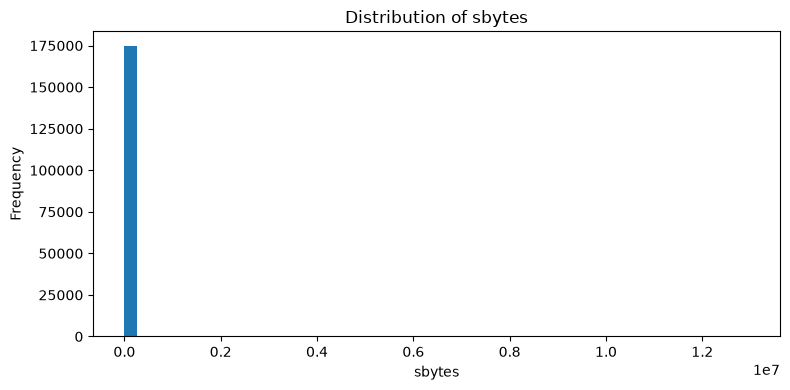

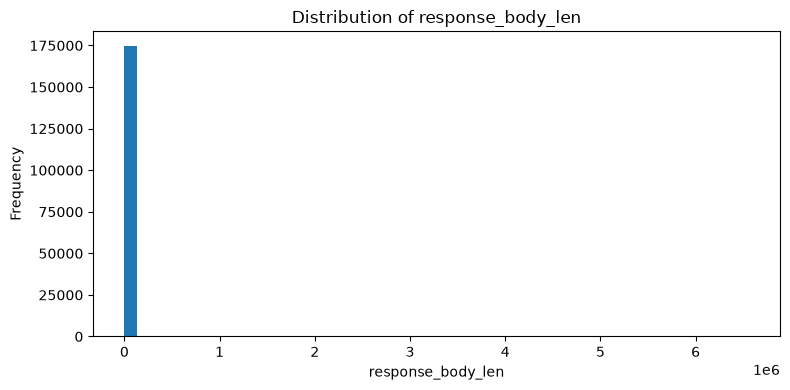

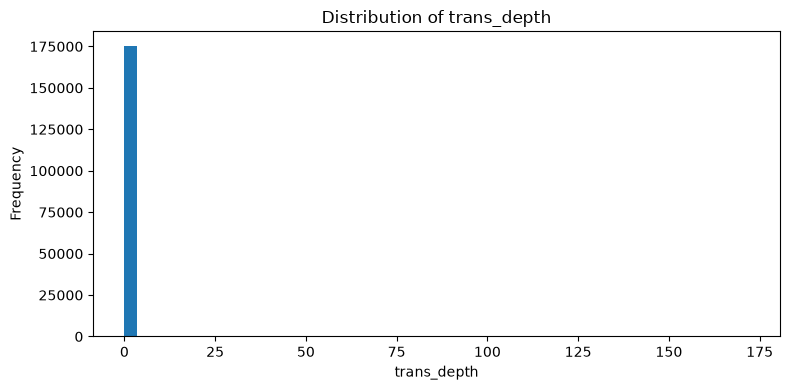

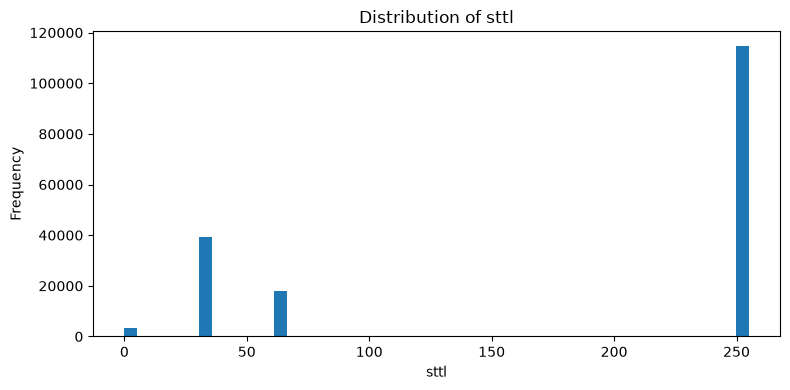

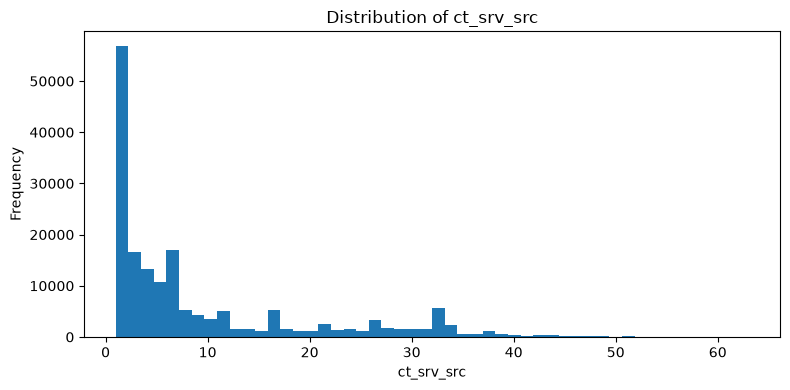

In [33]:
import matplotlib.pyplot as plt

features_to_plot = [
    "sbytes",
    "response_body_len",
    "trans_depth",
    "sttl",
    "ct_srv_src"
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    plt.hist(train_df[feature], bins=50)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

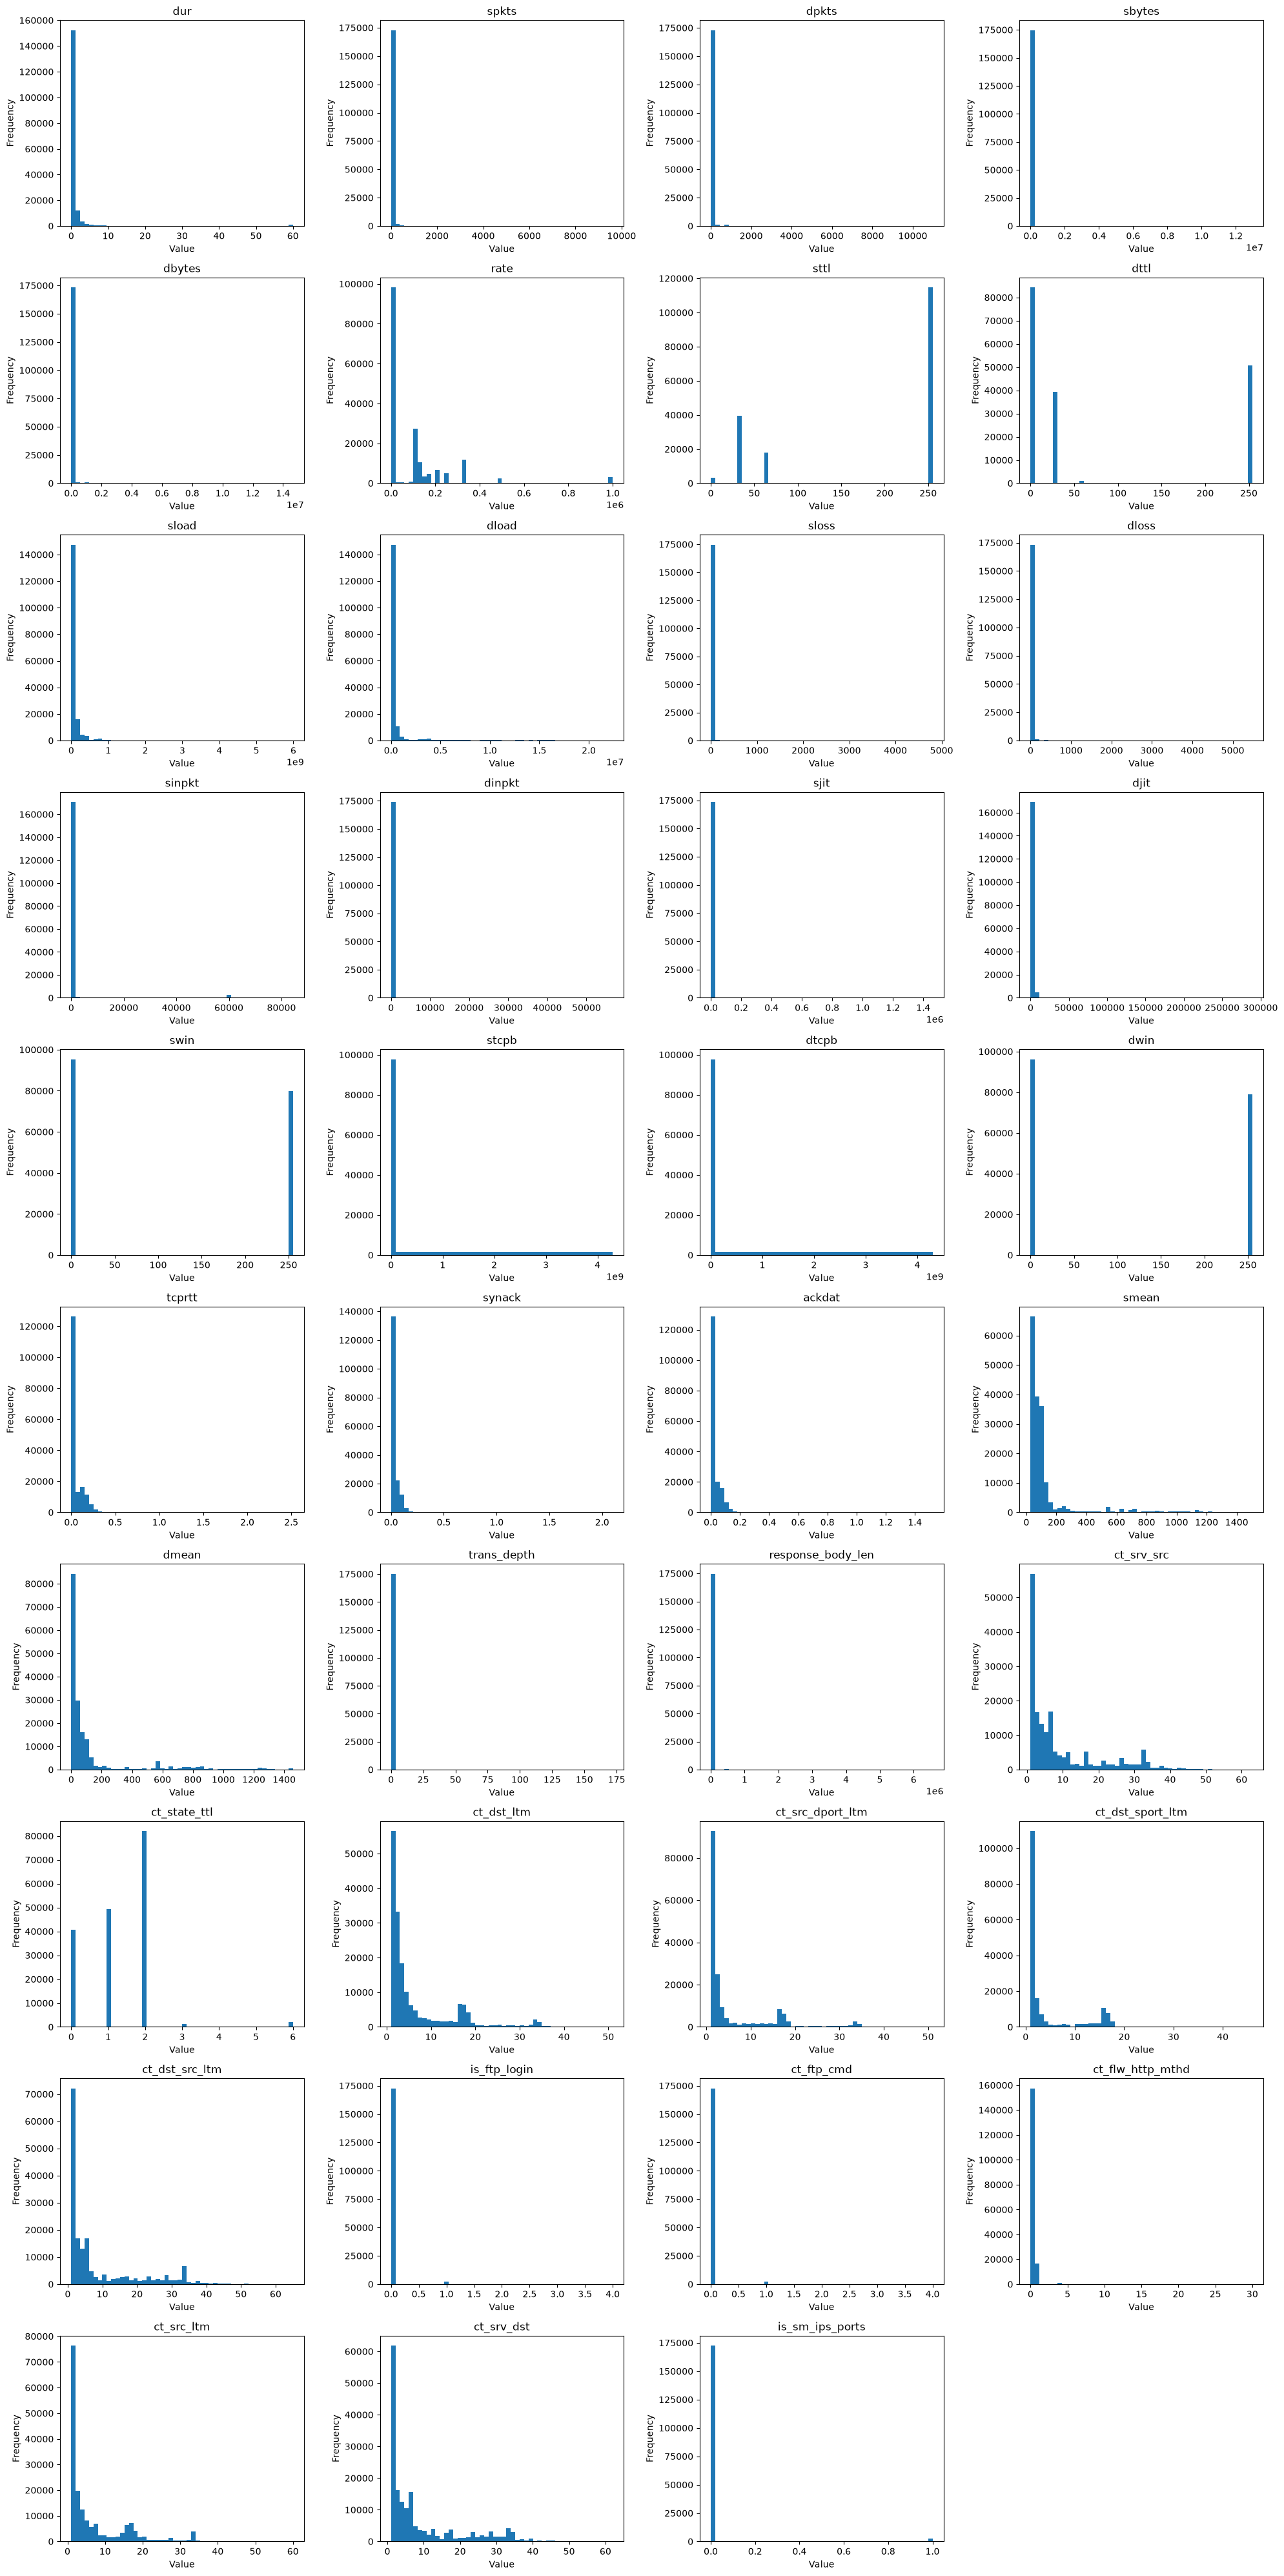

In [36]:
import matplotlib.pyplot as plt
import math

n_features = len(numerical_features)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(train_df[feature], bins=50)
    axes[i].set_title(feature)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
categorical_features = ["proto", "service", "state"]

for feature in categorical_features:
    print(f"\n===== {feature} =====")
    print(train_df[feature].value_counts())


===== proto =====
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
          ...  
rdp          98
netblt       98
igmp         18
icmp         15
rtp           1
Name: count, Length: 133, dtype: int64

===== service =====
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

===== state =====
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


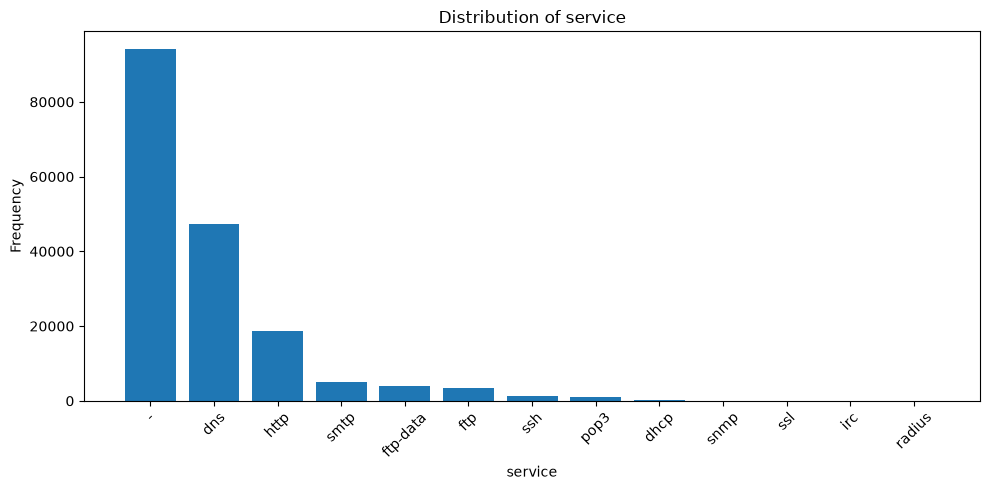

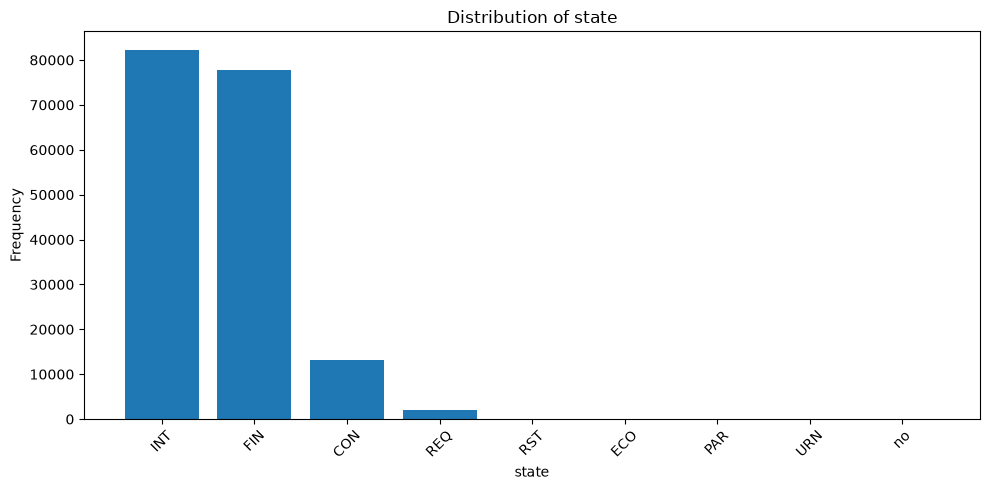

In [41]:
import matplotlib.pyplot as plt

categorical_features = [ "service", "state"]

for feature in categorical_features:

    counts = train_df[feature].value_counts()

    plt.figure(figsize=(10, 5))

    plt.bar(counts.index.astype(str), counts.values)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Distribution of States
state contains 9 categories and is strongly imbalanced.
INT (46.92%) and FIN (44.38%) are the dominant states, together
representing approximately 91.3% of the training records.
The remaining states are rare, with RST, ECO, PAR, URN and no
occurring at very low frequencies.

This frequency imbalance alone is not sufficient reason to remove
any category. Their relationship with the attack label will be
examined during bivariate analysis.

Service (`service`) contains 13 unique categories and has a highly imbalanced distribution.

The most frequent services are:
- `-`: 94,168 records (~53.7%)
- `dns`: 47,294 records (~27.0%)
- `http`: 18,724 records (~10.7%)
- `smtp`: 5,058 records
- `ftp-data`: 3,995 records
- `ftp`: 3,428 records
- `ssh`: 1,302 records
## Distrubution of Services 
Several categories are extremely rare, with `PAR`, `URN`, and `no` appearing only once.

The `-` category is dominant, representing more than half of the training data. However, frequency imbalance alone does not mean that a category or feature should be removed. Its relationship with the attack label will be examined during bivariate analysis.

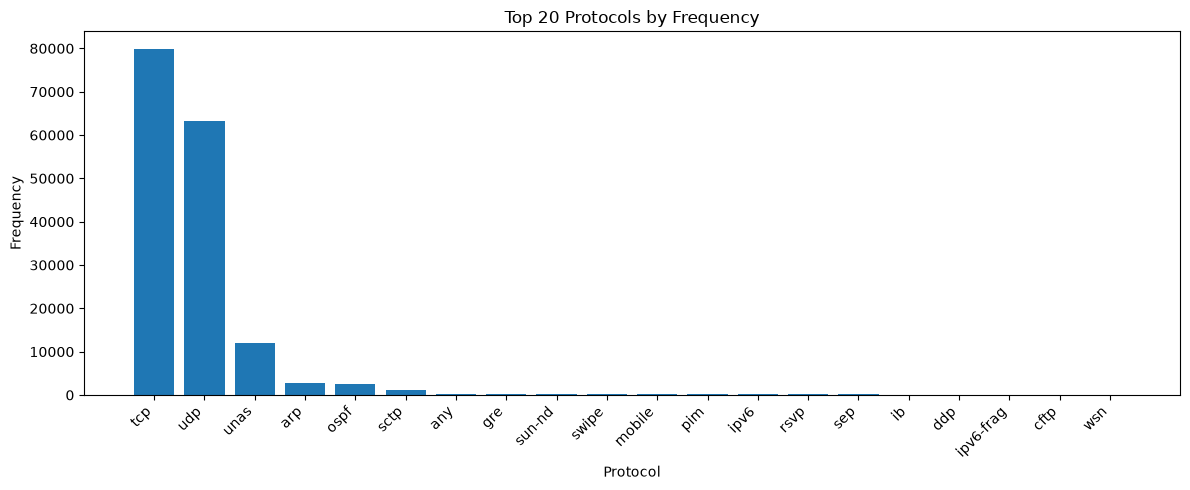

In [42]:
import matplotlib.pyplot as plt

# Top 20 protocols
proto_counts = train_df["proto"].value_counts().head(20)

plt.figure(figsize=(12, 5))

plt.bar(proto_counts.index.astype(str), proto_counts.values)

plt.title("Top 20 Protocols by Frequency")
plt.xlabel("Protocol")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Categorical Feature Distribution

### Protocol (`proto`)

- Number of unique protocols: **133**
- The distribution is highly concentrated in a few protocols.
- The most frequent protocols are:
  - `tcp`: **79,946**
  - `udp`: **63,283**
  - `unas`: **12,084**
  - `arp`: **2,859**
  - `ospf`: **2,595**
- Several protocols are very rare. For example, `rtp` occurs only **1** time.
- Since there are 133 categories, the visualization shows only the **top 20 protocols** for readability.
- **Observation:** `proto` has high cardinality and a strongly imbalanced frequency distribution.
- Rare protocols are **not removed at this stage**. Their relationship with the target will be examined during bivariate analysis.

### Service (`service`)

- Number of unique services: **13**
- The distribution is highly concentrated in a few services.
- The most frequent services are:
  - `-`: **94,168**
  - `dns`: **47,294**
  - `http`: **18,724**
  - `smtp`: **5,058**
  - `ftp-data`: **3,995**
  - `ftp`: **3,428**
  - `ssh`: **1,302**
- Several services occur very rarely, with some categories appearing only once.
- **Observation:** `service` has low cardinality but a strongly imbalanced frequency distribution.
- The `-` category is dominant, accounting for approximately **53.7%** of the training records.
- No service is removed based on this observation alone.

### Conclusion

The categorical features show substantial frequency imbalance:

- `proto`: **133 categories**, highly concentrated in a few protocols.
- `service`: **13 categories**, dominated by `-`, `dns`, and `http`.
- `state`: **9 categories**, with a few states accounting for most observations.

These observations describe the **distribution of the features only**. They do not determine whether a feature is useful for attack detection. Feature usefulness will be investigated in the **bivariate analysis against `label`**.

In [43]:
print(train_df["state"].value_counts())

state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


In [44]:
print(train_df["state"].value_counts(normalize=True).mul(100).round(2))

state
INT    46.92
FIN    44.38
CON     7.50
REQ     1.14
RST     0.05
ECO     0.01
PAR     0.00
URN     0.00
no      0.00
Name: proportion, dtype: float64


## Bivariate Analysis

## Categorical Bivariate Analysis

In [47]:
proto_analysis = (
    train_df.groupby("proto")["label"]
    .agg(
        count="count",
        attack_rate="mean"
    )
)

proto_analysis["attack_rate"] *= 100

proto_analysis = proto_analysis.sort_values(
    "count",
    ascending=False
)

print(proto_analysis)

       count  attack_rate
proto                    
tcp    79946    51.065719
udp    63283    78.000411
unas   12084   100.000000
arp     2859     0.000000
ospf    2595    97.533719
...      ...          ...
hmp       98   100.000000
rdp       98   100.000000
igmp      18     0.000000
icmp      15     0.000000
rtp        1     0.000000

[133 rows x 2 columns]


In [48]:
service_analysis = (
    train_df.groupby("service")["label"]
    .agg(
        count="count",
        attack_rate="mean"
    )
)

service_analysis["attack_rate"] *= 100

service_analysis = service_analysis.sort_values(
    "count",
    ascending=False
)

print(service_analysis)

          count  attack_rate
service                     
-         94168    61.226744
dns       47294    84.156553
http      18724    71.437727
smtp       5058    68.782127
ftp-data   3995    36.120150
ftp        3428    64.469078
ssh        1302     0.844854
pop3       1105    99.638009
dhcp         94   100.000000
snmp         80    98.750000
ssl          56   100.000000
irc          25   100.000000
radius       12    83.333333


In [49]:
state_analysis = (
    train_df.groupby("state")["label"]
    .agg(
        count="count",
        attack_rate="mean"
    )
)

state_analysis["attack_rate"] *= 100

state_analysis = state_analysis.sort_values(
    "count",
    ascending=False
)

print(state_analysis)

       count  attack_rate
state                    
INT    82275    93.053783
FIN    77825    52.232573
CON    13152     8.006387
REQ     1991    53.540934
RST       83    14.457831
ECO       12     0.000000
PAR        1     0.000000
URN        1     0.000000
no         1     0.000000


Categorical Features vs Attack Label

Bivariate analysis was performed to examine how each categorical feature relates to the target variable label (0 = Normal, 1 = Attack). For each category, both the number of observations and the attack rate were examined.

proto vs label

The attack rate varies considerably between network protocols. Common protocols such as udp have a relatively high attack rate (78.00%), while tcp has a more balanced distribution (51.07%). unas and ospf also show very high attack rates. Some rare protocols show 0% or 100% attack rates, but these values are less reliable because of their small sample sizes.

This indicates that proto may contain useful information for distinguishing attack and normal traffic. Rare categories should not be removed solely based on their observed attack rate.

service vs label

The attack rate also varies substantially across services. Common services such as dns (84.16%), http (71.44%), and smtp (68.78%) have relatively high attack rates, while ssh has a very low attack rate (0.84%). ftp-data has a lower attack rate of 36.12%.

Several rare services show extreme attack rates, but their small sample sizes make these estimates less reliable. Therefore, category frequency and attack rate should be considered together.

state vs label

state shows a strong relationship with the target. The common INT state has an attack rate of 93.05%, while CON has only 8.01%. FIN is more balanced with an attack rate of 52.23%.

Because these observations are based on large sample sizes, the differences are more reliable than the extreme rates observed for very rare categories.

Overall Finding

The categorical bivariate analysis suggests that proto, service, and especially state contain potentially useful information for attack detection. However, this analysis alone is not used to remove or select features. The findings will be validated later using feature engineering, model performance, and error analysis.

## Numerical Bivariate Analysis

In [50]:
numeric_label_summary = train_df.groupby("label")[numerical_features].agg(
    ["median", "mean"]
)

print(numeric_label_summary)

            dur            spkts             dpkts             sbytes  \
         median      mean median       mean median       mean  median   
label                                                                   
0      0.038602  1.017177   12.0  30.725482   10.0  38.057696  1470.0   
1      0.000009  1.519969    2.0  15.405946    0.0  10.012619   200.0   

                     dbytes                ... ct_ftp_cmd            \
               mean  median          mean  ...     median      mean   
label                                      ...                        
0       4105.702929  1112.0  31049.463143  ...        0.0  0.016982   
1      11068.655357     0.0   7364.456256  ...        0.0  0.013994   

      ct_flw_http_mthd           ct_src_ltm           ct_srv_dst             \
                median      mean     median      mean     median       mean   
label                                                                         
0                  0.0  0.116893        3

In [51]:
median_comparison = train_df.groupby("label")[numerical_features].median().T

median_comparison["absolute_difference"] = (
    median_comparison[1] - median_comparison[0]
).abs()

median_comparison = median_comparison.sort_values(
    "absolute_difference",
    ascending=False
)

print(median_comparison)

label                         0             1  absolute_difference
stcpb              1.180207e+09  0.000000e+00         1.180207e+09
dtcpb              1.152046e+09  0.000000e+00         1.152046e+09
sload              4.313277e+05  5.066666e+07         5.023534e+07
dload              3.361206e+05  0.000000e+00         3.361206e+05
rate               1.382257e+03  1.111111e+05         1.097289e+05
sbytes             1.470000e+03  2.000000e+02         1.270000e+03
dbytes             1.112000e+03  0.000000e+00         1.112000e+03
dwin               2.550000e+02  0.000000e+00         2.550000e+02
swin               2.550000e+02  0.000000e+00         2.550000e+02
sttl               3.100000e+01  2.540000e+02         2.230000e+02
dmean              8.900000e+01  0.000000e+00         8.900000e+01
sjit               5.442267e+01  0.000000e+00         5.442267e+01
dttl               2.900000e+01  0.000000e+00         2.900000e+01
djit               1.922622e+01  0.000000e+00         1.922622

In [52]:
from scipy.stats import mannwhitneyu
import pandas as pd

results = []

normal = train_df[train_df["label"] == 0]
attack = train_df[train_df["label"] == 1]

for feature in numerical_features:
    x = normal[feature].dropna()
    y = attack[feature].dropna()

    stat, p_value = mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    results.append({
        "feature": feature,
        "p_value": p_value
    })

mw_results = pd.DataFrame(results)

mw_results["significant"] = mw_results["p_value"] < 0.05

mw_results = mw_results.sort_values("p_value")

mw_results

,feature,p_value,significant
0,dur,0.000000e+00,True
1,spkts,0.000000e+00,True
2,dpkts,0.000000e+00,True
3,sbytes,0.000000e+00,True
4,dbytes,0.000000e+00,True
5,rate,0.000000e+00,True
6,sttl,0.000000e+00,True
7,dttl,0.000000e+00,True
8,sload,0.000000e+00,True
9,dload,0.000000e+00,True


Mann–Whitney U Test — Numerical Features

The Mann–Whitney U test was used to determine whether each numerical feature has a statistically significant difference between Normal (label 0) and Attack (label 1) traffic.

Results
All 39 numerical features have a p-value below 0.05.
Therefore, the null hypothesis was rejected for all 39 features.
This means there is statistical evidence that the distributions of these features differ between Normal and Attack traffic.
The smallest p-values were observed for features such as dur, spkts, dpkts, sbytes, dbytes, rate, sttl, and dttl.
Even features such as is_ftp_login and ct_ftp_cmd were statistically significant, although their p-values were much larger than the features above.
Because the dataset contains 175,341 observations, very small differences can produce extremely small p-values.
Important Interpretation

Statistical significance does not mean that a feature is important for prediction.

The test only tells us:

"There is evidence that this feature behaves differently between Normal and Attack traffic."

In [53]:
from scipy.stats import mannwhitneyu
import pandas as pd

results = []

normal = train_df[train_df["label"] == 0]
attack = train_df[train_df["label"] == 1]

for feature in numerical_features:

    x = normal[feature].dropna()
    y = attack[feature].dropna()

    u_stat, p_value = mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    n1 = len(x)
    n2 = len(y)

    rank_biserial = (2 * u_stat) / (n1 * n2) - 1

    results.append({
        "feature": feature,
        "p_value": p_value,
        "effect_size": rank_biserial
    })

effect_results = pd.DataFrame(results)

effect_results["abs_effect_size"] = (
    effect_results["effect_size"].abs()
)

effect_results = effect_results.sort_values(
    "abs_effect_size",
    ascending=False
)

effect_results

,feature,p_value,effect_size,abs_effect_size
6,sttl,0.000000e+00,-0.762875,0.762875
28,ct_state_ttl,0.000000e+00,-0.741220,0.741220
9,dload,0.000000e+00,0.730593,0.730593
24,dmean,0.000000e+00,0.637597,0.637597
4,dbytes,0.000000e+00,0.573444,0.573444
2,dpkts,0.000000e+00,0.565770,0.565770
31,ct_dst_sport_ltm,0.000000e+00,-0.462412,0.462412
11,dloss,0.000000e+00,0.438031,0.438031
10,sloss,0.000000e+00,0.429952,0.429952
3,sbytes,0.000000e+00,0.413370,0.413370


Effect Size Analysis

Effect size analysis measures how large the difference is between normal traffic (label = 0) and attack traffic (label = 1) for each numerical feature.

p-value tells us whether the difference is statistically significant.
Effect size tells us the magnitude of the difference.
Absolute effect size is used to rank features by the strength of their difference, regardless of direction.
Key Findings

Features with relatively large differences between normal and attack traffic include:

sttl — 0.763
ct_state_ttl — 0.741
dload — 0.731
dmean — 0.638
dbytes — 0.573
dpkts — 0.566
ct_dst_sport_ltm — 0.462
dloss — 0.438
sloss — 0.430
sbytes — 0.413
spkts — 0.412

These features show relatively strong distributional differences between normal and attack traffic and may contain useful information for classification.

Some features have statistically significant p-values but very small effect sizes. For example:

response_body_len — 0.030
ct_flw_http_mthd — 0.013
trans_depth — 0.013
ct_ftp_cmd — 0.003
is_ftp_login — 0.003

This demonstrates that statistical significance does not necessarily mean practical importance. Because the dataset is large, even very small differences can produce extremely small p-values.

Conclusion

Effect size gives a better indication of the practical magnitude of the difference between normal and attack traffic. However, we should not remove features solely based on effect size or p-value. Feature redundancy, model performance, and error analysis should also be considered before making final feature-selection decisions.

In [54]:
corr_matrix = train_df[numerical_features].corr(method="spearman")

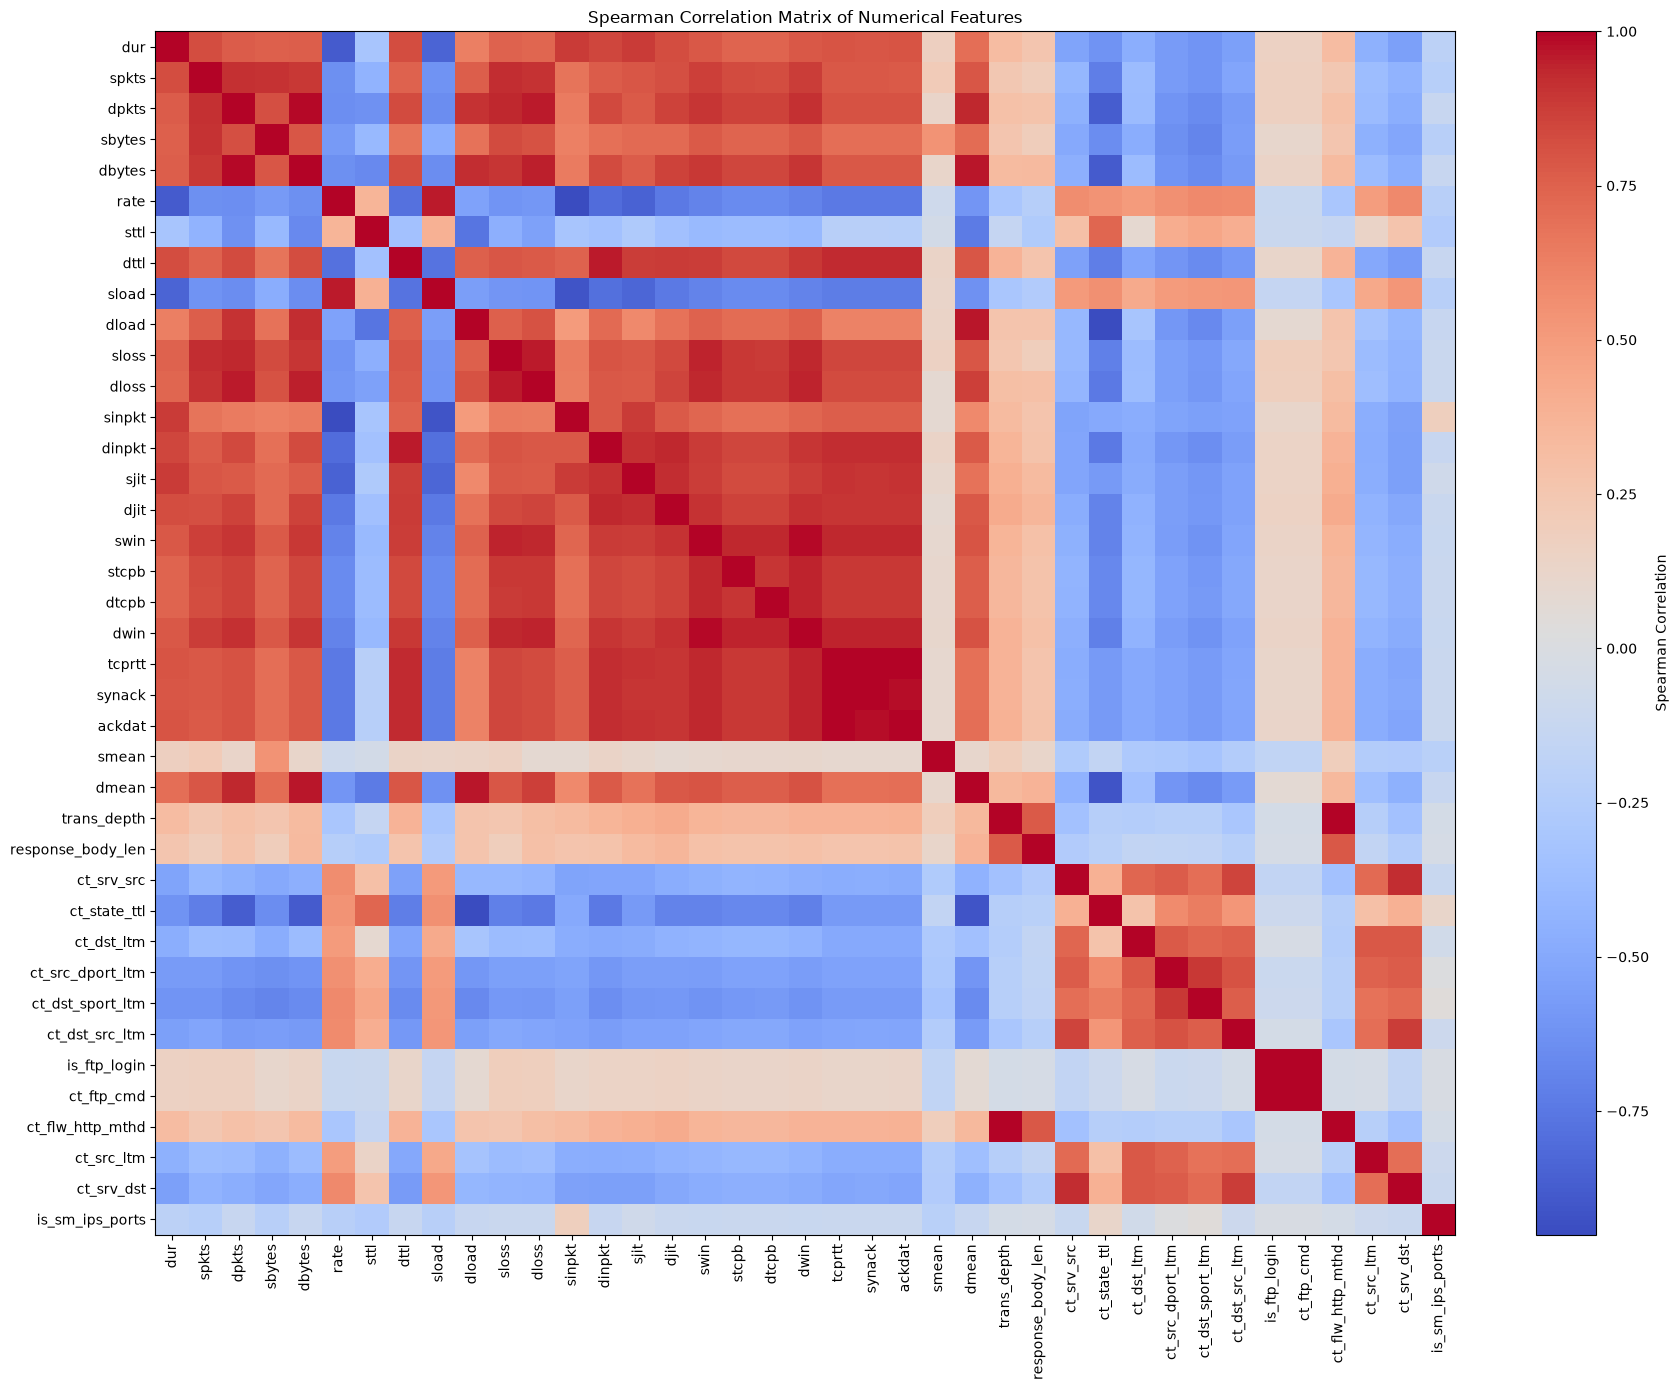

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))

plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Spearman Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Spearman Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [57]:
import numpy as np
import pandas as pd

corr_matrix = train_df[numerical_features].corr()

# Keep only the upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "correlation"
    })
)

high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["abs_correlation"] >= 0.8
    ]
    .sort_values("abs_correlation", ascending=False)
)

high_corr_pairs

,feature_1,feature_2,correlation,abs_correlation
1321,is_ftp_login,ct_ftp_cmd,1.000000,1.000000
167,dbytes,dloss,0.996504,0.996504
127,sbytes,sloss,0.996109,0.996109
643,swin,dwin,0.990140,0.990140
1090,ct_srv_src,ct_srv_dst,0.980323,0.980323
89,dpkts,dloss,0.978636,0.978636
1285,ct_dst_src_ltm,ct_srv_dst,0.972370,0.972370
82,dpkts,dbytes,0.971907,0.971907
49,spkts,sloss,0.971069,0.971069
1085,ct_srv_src,ct_dst_src_ltm,0.967138,0.967138


In [63]:
# ---------------------------------------------------------
# Correlation + Effect Size Analysis
# ---------------------------------------------------------

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Thresholds
# ---------------------------------------------------------

CORR_THRESHOLD = 0.90
EFFECT_SIZE_THRESHOLD = 0.20


# ---------------------------------------------------------
# 2. Effect size lookup
# ---------------------------------------------------------
# effect_results was created earlier using Mann-Whitney U.
#
# Expected columns:
# feature
# p_value
# effect_size
# abs_effect_size

effect_lookup = (
    effect_results
    .set_index("feature")["abs_effect_size"]
)


# ---------------------------------------------------------
# 3. Create upper-triangle correlation pairs
# ---------------------------------------------------------

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]


# ---------------------------------------------------------
# 4. Calculate absolute correlation
# ---------------------------------------------------------

corr_pairs["abs_correlation"] = (
    corr_pairs["correlation"].abs()
)


# ---------------------------------------------------------
# 5. Keep only highly correlated pairs
# ---------------------------------------------------------

high_corr_pairs = corr_pairs[
    corr_pairs["abs_correlation"] >= CORR_THRESHOLD
].copy()


# ---------------------------------------------------------
# 6. Attach effect size of each feature
# ---------------------------------------------------------

high_corr_pairs["effect_size_1"] = (
    high_corr_pairs["feature_1"]
    .map(effect_lookup)
)

high_corr_pairs["effect_size_2"] = (
    high_corr_pairs["feature_2"]
    .map(effect_lookup)
)


# ---------------------------------------------------------
# 7. Difference between effect sizes
# ---------------------------------------------------------

high_corr_pairs["effect_size_difference"] = (
    high_corr_pairs["effect_size_1"]
    -
    high_corr_pairs["effect_size_2"]
).abs()


# ---------------------------------------------------------
# 8. Identify stronger feature
# ---------------------------------------------------------

high_corr_pairs["stronger_feature"] = np.where(
    high_corr_pairs["effect_size_1"]
    >=
    high_corr_pairs["effect_size_2"],

    high_corr_pairs["feature_1"],
    high_corr_pairs["feature_2"]
)


high_corr_pairs["weaker_feature"] = np.where(
    high_corr_pairs["effect_size_1"]
    >=
    high_corr_pairs["effect_size_2"],

    high_corr_pairs["feature_2"],
    high_corr_pairs["feature_1"]
)


# ---------------------------------------------------------
# 9. Recommendation logic
# ---------------------------------------------------------

def make_recommendation(row):

    e1 = row["effect_size_1"]
    e2 = row["effect_size_2"]
    corr = row["abs_correlation"]

    # Missing effect size
    if pd.isna(e1) or pd.isna(e2):
        return "CHECK — EFFECT SIZE MISSING"

    # Both features have meaningful class separation
    if (
        e1 >= EFFECT_SIZE_THRESHOLD
        and
        e2 >= EFFECT_SIZE_THRESHOLD
    ):

        # Extremely correlated
        if corr >= 0.95:

            if e1 >= e2:
                return (
                    f"KEEP {row['feature_1']} — "
                    f"DROP {row['feature_2']} CANDIDATE"
                )
            else:
                return (
                    f"KEEP {row['feature_2']} — "
                    f"DROP {row['feature_1']} CANDIDATE"
                )

        # Highly correlated but not almost identical
        return "KEEP BOTH — VERIFY WITH MODEL"

    # Feature 1 meaningful, feature 2 weak
    elif e1 >= EFFECT_SIZE_THRESHOLD:

        return (
            f"KEEP {row['feature_1']} — "
            f"DROP {row['feature_2']} CANDIDATE"
        )

    # Feature 2 meaningful, feature 1 weak
    elif e2 >= EFFECT_SIZE_THRESHOLD:

        return (
            f"KEEP {row['feature_2']} — "
            f"DROP {row['feature_1']} CANDIDATE"
        )

    # Both weak
    else:

        return "BOTH WEAK — INVESTIGATE / POSSIBLE DROP"


high_corr_pairs["recommendation"] = (
    high_corr_pairs.apply(
        make_recommendation,
        axis=1
    )
)


# ---------------------------------------------------------
# 10. Sort BEFORE selecting final columns
# ---------------------------------------------------------

high_corr_pairs = (
    high_corr_pairs
    .sort_values(
        by="abs_correlation",
        ascending=False
    )
)


# ---------------------------------------------------------
# 11. Final analysis table
# ---------------------------------------------------------

correlation_effect_analysis = high_corr_pairs[
    [
        "feature_1",
        "feature_2",
        "correlation",
        "abs_correlation",
        "effect_size_1",
        "effect_size_2",
        "effect_size_difference",
        "stronger_feature",
        "weaker_feature",
        "recommendation"
    ]
].reset_index(drop=True)


correlation_effect_analysis

,feature_1,feature_2,correlation,abs_correlation,effect_size_1,effect_size_2,effect_size_difference,stronger_feature,weaker_feature,recommendation
0,is_ftp_login,ct_ftp_cmd,1.000000,1.000000,0.003386,0.003386,0.000000,is_ftp_login,ct_ftp_cmd,BOTH WEAK — INVESTIGATE / POSSIBLE DROP
1,dbytes,dloss,0.996504,0.996504,0.573444,0.438031,0.135413,dbytes,dloss,KEEP dbytes — DROP dloss CANDIDATE
2,sbytes,sloss,0.996109,0.996109,0.413370,0.429952,0.016582,sloss,sbytes,KEEP sloss — DROP sbytes CANDIDATE
3,swin,dwin,0.990140,0.990140,0.356435,0.341150,0.015285,swin,dwin,KEEP swin — DROP dwin CANDIDATE
4,ct_srv_src,ct_srv_dst,0.980323,0.980323,0.115894,0.086261,0.029633,ct_srv_src,ct_srv_dst,BOTH WEAK — INVESTIGATE / POSSIBLE DROP
5,dpkts,dloss,0.978636,0.978636,0.565770,0.438031,0.127740,dpkts,dloss,KEEP dpkts — DROP dloss CANDIDATE
6,ct_dst_src_ltm,ct_srv_dst,0.972370,0.972370,0.269478,0.086261,0.183217,ct_dst_src_ltm,ct_srv_dst,KEEP ct_dst_src_ltm — DROP ct_srv_dst CANDIDATE
7,dpkts,dbytes,0.971907,0.971907,0.565770,0.573444,0.007674,dbytes,dpkts,KEEP dbytes — DROP dpkts CANDIDATE
8,spkts,sloss,0.971069,0.971069,0.411718,0.429952,0.018234,sloss,spkts,KEEP sloss — DROP spkts CANDIDATE
9,ct_srv_src,ct_dst_src_ltm,0.967138,0.967138,0.115894,0.269478,0.153584,ct_dst_src_ltm,ct_srv_src,KEEP ct_dst_src_ltm — DROP ct_srv_src CANDIDATE


In [65]:
# ---------------------------------------------------------
# Create Groups of Highly Correlated Features
# No external libraries required
# ---------------------------------------------------------

# Get feature pairs from the highly correlated pairs table
pairs = high_corr_pairs[
    ["feature_1", "feature_2"]
].copy()


# Build groups using connected components
groups = []

for _, row in pairs.iterrows():

    feature_1 = row["feature_1"]
    feature_2 = row["feature_2"]

    # Find groups containing either feature
    matching_groups = []

    for group in groups:
        if feature_1 in group or feature_2 in group:
            matching_groups.append(group)

    # If neither feature exists in a group,
    # create a new group
    if not matching_groups:
        groups.append({feature_1, feature_2})

    else:
        # Merge all matching groups
        new_group = {feature_1, feature_2}

        for group in matching_groups:
            new_group.update(group)
            groups.remove(group)

        groups.append(new_group)


# Convert groups to DataFrame
group_results = []

for i, group in enumerate(groups, start=1):

    group_results.append({
        "group_id": i,
        "features": sorted(group),
        "n_features": len(group)
    })


correlation_groups = pd.DataFrame(group_results)

# Largest groups first
correlation_groups = correlation_groups.sort_values(
    "n_features",
    ascending=False
).reset_index(drop=True)

correlation_groups

,group_id,features,n_features
0,4,"[ct_dst_src_ltm, ct_srv_dst, ct_srv_src]",3
1,3,"[dbytes, dloss, dpkts]",3
2,6,"[ackdat, synack, tcprtt]",3
3,5,"[sbytes, sloss, spkts]",3
4,8,"[ct_dst_ltm, ct_dst_sport_ltm, ct_src_dport_ltm]",3
5,2,"[dwin, swin]",2
6,1,"[ct_ftp_cmd, is_ftp_login]",2
7,7,"[is_sm_ips_ports, sinpkt]",2


## Multivariative Analysis

In [74]:
# =========================================================
# Multivariate EDA — PCA
# =========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Numerical features only
X = train_df[numerical_features].copy()
y = train_df["label"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_results = pd.DataFrame({
    "component": np.arange(1, len(explained_variance) + 1),
    "explained_variance_ratio": explained_variance,
    "cumulative_variance": cumulative_variance
})

pca_results.head(15)

,component,explained_variance_ratio,cumulative_variance
0,1,0.254466,0.254466
1,2,0.098383,0.352849
2,3,0.091379,0.444228
3,4,0.077081,0.521309
4,5,0.061527,0.582836
5,6,0.054197,0.637032
6,7,0.050847,0.687879
7,8,0.047432,0.735311
8,9,0.030449,0.765760
9,10,0.029633,0.795393


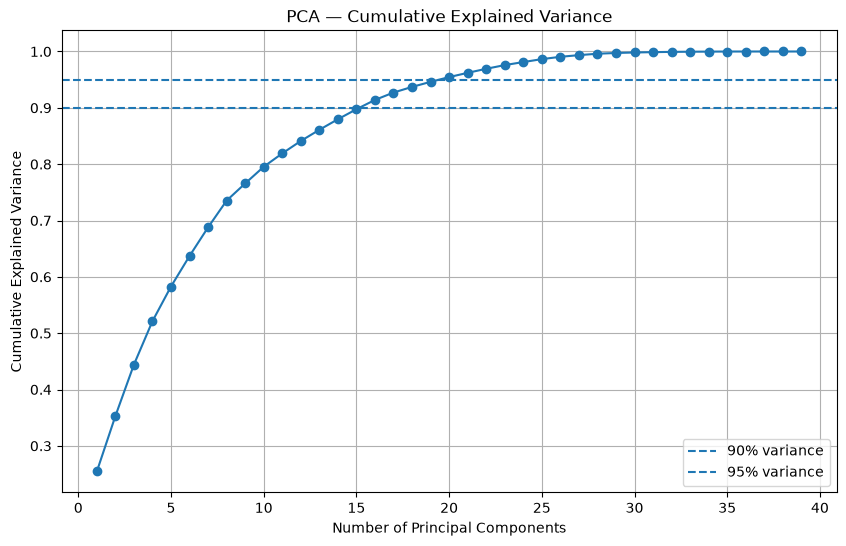

In [67]:
# =========================================================
# Cumulative Explained Variance
# =========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% variance"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

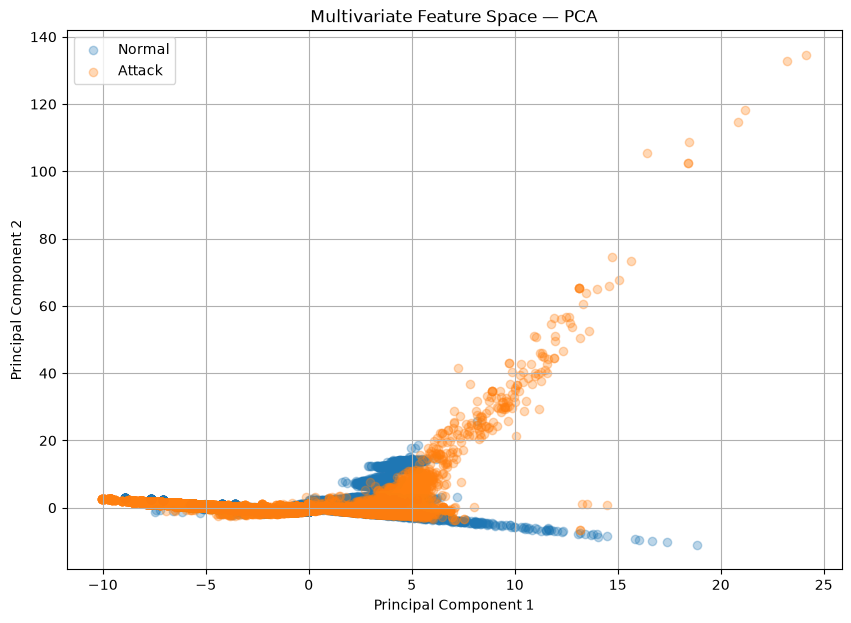

In [68]:
# =========================================================
# PCA — First Two Components
# =========================================================

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_2d_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "label": y.values
})

plt.figure(figsize=(10, 7))

for label, name in [(0, "Normal"), (1, "Attack")]:
    subset = pca_2d_df[pca_2d_df["label"] == label]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.3,
        label=name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Multivariate Feature Space — PCA")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# ---------------------------------------------------------
# PCA Feature Contributions: PC1 - PC5
# ---------------------------------------------------------

import pandas as pd
import numpy as np

N_COMPONENTS = 5

# PCA components:
# rows    = principal components
# columns = original features
loadings = pd.DataFrame(
    pca.components_[:N_COMPONENTS].T,
    index=numerical_features,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)]
)

# Absolute loadings = strength of contribution
abs_loadings = loadings.abs()

# ---------------------------------------------------------
# 1. Top contributors for each principal component
# ---------------------------------------------------------

for pc in loadings.columns:

    result = pd.DataFrame({
        "feature": loadings[pc].index,
        "loading": loadings[pc].values,
        "abs_loading": abs_loadings[pc].values
    })

    result = result.sort_values(
        "abs_loading",
        ascending=False
    )

    print("\n" + "=" * 60)
    print(f"Top contributors to {pc}")
    print("=" * 60)

    display(result.head(10))


Top contributors to PC1


,feature,loading,abs_loading
19,dwin,0.267562,0.267562
16,swin,0.265020,0.265020
32,ct_dst_src_ltm,-0.262512,0.262512
37,ct_srv_dst,-0.258540,0.258540
27,ct_srv_src,-0.255617,0.255617
31,ct_dst_sport_ltm,-0.253897,0.253897
30,ct_src_dport_ltm,-0.253373,0.253373
29,ct_dst_ltm,-0.244517,0.244517
36,ct_src_ltm,-0.233700,0.233700
7,dttl,0.227245,0.227245



Top contributors to PC2


,feature,loading,abs_loading
2,dpkts,0.443602,0.443602
11,dloss,0.414544,0.414544
4,dbytes,0.413412,0.413412
1,spkts,0.278259,0.278259
24,dmean,0.265904,0.265904
26,response_body_len,0.234688,0.234688
10,sloss,0.195576,0.195576
3,sbytes,0.189483,0.189483
9,dload,0.156274,0.156274
6,sttl,-0.137311,0.137311



Top contributors to PC3


,feature,loading,abs_loading
20,tcprtt,0.321963,0.321963
21,synack,0.304827,0.304827
22,ackdat,0.304140,0.304140
7,dttl,0.277007,0.277007
30,ct_src_dport_ltm,0.248726,0.248726
29,ct_dst_ltm,0.238990,0.238990
32,ct_dst_src_ltm,0.227644,0.227644
36,ct_src_ltm,0.223564,0.223564
27,ct_srv_src,0.222822,0.222822
37,ct_srv_dst,0.216974,0.216974



Top contributors to PC4


,feature,loading,abs_loading
3,sbytes,0.490194,0.490194
10,sloss,0.483064,0.483064
1,spkts,0.439789,0.439789
23,smean,0.215252,0.215252
24,dmean,-0.205652,0.205652
0,dur,0.177408,0.177408
9,dload,-0.172761,0.172761
28,ct_state_ttl,0.169563,0.169563
6,sttl,0.156001,0.156001
8,sload,0.109685,0.109685



Top contributors to PC5


,feature,loading,abs_loading
4,dbytes,0.311424,0.311424
11,dloss,0.298136,0.298136
28,ct_state_ttl,0.296213,0.296213
6,sttl,0.286967,0.286967
9,dload,-0.286552,0.286552
2,dpkts,0.237926,0.237926
26,response_body_len,0.235769,0.235769
10,sloss,-0.206207,0.206207
3,sbytes,-0.196969,0.196969
20,tcprtt,0.190408,0.190408


In [77]:
# ---------------------------------------------------------
# Class-Conditional Analysis of PC1-PC5
# ---------------------------------------------------------

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------
# 1. Create dataframe containing PC1-PC5 + label
# ---------------------------------------------------------

pc_df = pd.DataFrame(
    X_pca[:, :5],
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"],
    index=train_df.index
)

pc_df["label"] = train_df["label"].values

# ---------------------------------------------------------
# 2. Compare Normal vs Attack for each PC
# ---------------------------------------------------------

results = []

normal = pc_df[pc_df["label"] == 0]
attack = pc_df[pc_df["label"] == 1]

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:

    x = normal[pc].dropna()
    y = attack[pc].dropna()

    # Mann-Whitney U test
    u_stat, p_value = mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    # Rank-biserial effect size
    n1 = len(x)
    n2 = len(y)

    effect_size = (2 * u_stat) / (n1 * n2) - 1

    results.append({
        "component": pc,
        "normal_median": x.median(),
        "attack_median": y.median(),
        "normal_mean": x.mean(),
        "attack_mean": y.mean(),
        "normal_std": x.std(),
        "attack_std": y.std(),
        "p_value": p_value,
        "effect_size": effect_size,
        "abs_effect_size": abs(effect_size)
    })

pc_class_results = pd.DataFrame(results)

# ---------------------------------------------------------
# 3. Sort by class-separation effect
# ---------------------------------------------------------

pc_class_results = pc_class_results.sort_values(
    "abs_effect_size",
    ascending=False
).reset_index(drop=True)

pc_class_results

,component,normal_median,attack_median,normal_mean,attack_mean,normal_std,attack_std,p_value,effect_size,abs_effect_size
0,PC5,-0.855908,0.435381,-0.833437,0.391085,1.604088,1.356195,0.0,-0.539690,0.539690
1,PC4,-0.318473,0.141443,-0.570727,0.267810,1.020805,1.924391,0.0,-0.459359,0.459359
2,PC1,2.078299,-1.023835,1.591405,-0.746757,1.720022,3.383323,0.0,0.374737,0.374737
3,PC3,-1.011476,0.740018,-0.784581,0.368159,1.891443,1.770015,0.0,-0.327319,0.327319
4,PC2,0.200832,-0.597698,0.507018,-0.237915,2.015345,1.885294,0.0,0.313510,0.313510


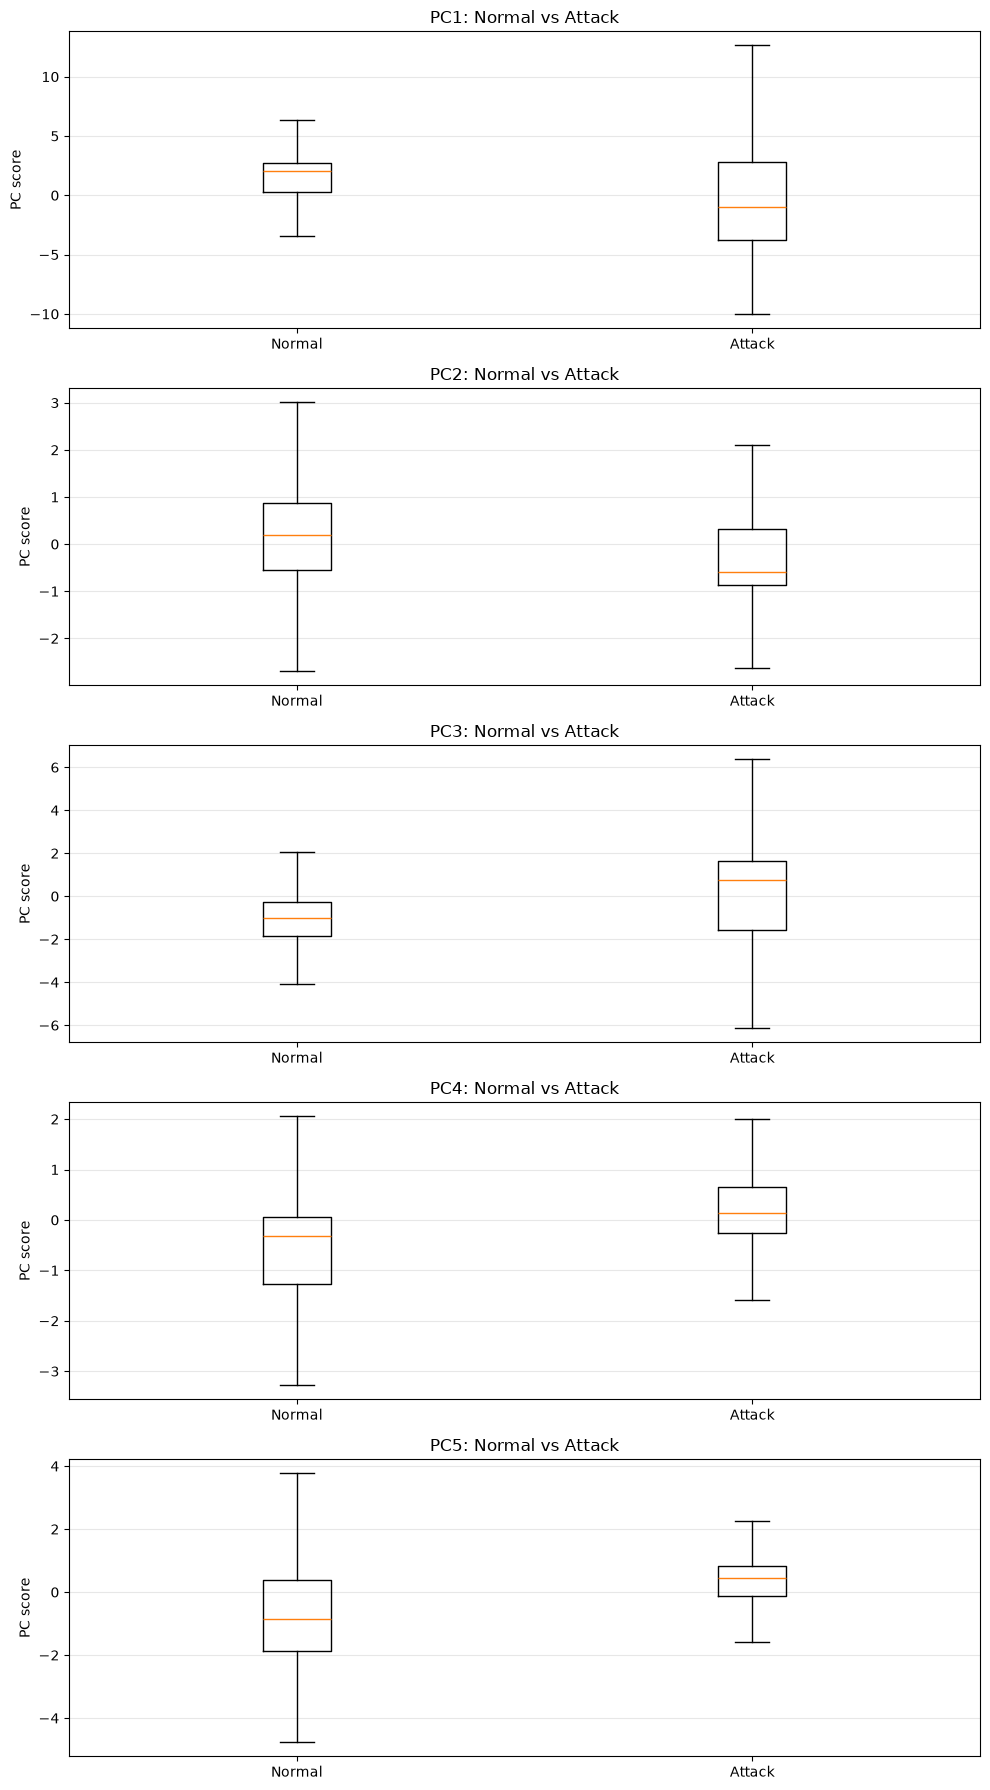

In [80]:
# ---------------------------------------------------------
# Boxplots: Normal vs Attack for PC1-PC5
# ---------------------------------------------------------

import matplotlib.pyplot as plt

pcs = ["PC1", "PC2", "PC3", "PC4", "PC5"]

fig, axes = plt.subplots(
    5, 1,
    figsize=(10, 18)
)

for ax, pc in zip(axes, pcs):

    ax.boxplot(
        [
            normal[pc].values,
            attack[pc].values
        ],
        tick_labels=["Normal", "Attack"],
        showfliers=False
    )

    ax.set_title(f"{pc}: Normal vs Attack")
    ax.set_ylabel("PC score")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [81]:
# ---------------------------------------------------------
# PCA Loading Matrix: PC1-PC5
# ---------------------------------------------------------

pcs = ["PC1", "PC2", "PC3", "PC4", "PC5"]

loading_matrix = pd.DataFrame(
    pca.components_[:5].T,
    index=numerical_features,
    columns=pcs
)

# Absolute loadings
abs_loading_matrix = loading_matrix.abs()

# Maximum contribution to any of PC1-PC5
loading_analysis = loading_matrix.copy()

loading_analysis["max_abs_loading"] = (
    abs_loading_matrix.max(axis=1)
)

loading_analysis["strongest_pc"] = (
    abs_loading_matrix.idxmax(axis=1)
)

# Sort by strongest contribution
loading_analysis = loading_analysis.sort_values(
    "max_abs_loading",
    ascending=False
)

loading_analysis

,PC1,PC2,PC3,PC4,PC5,max_abs_loading,strongest_pc
sbytes,0.030834,0.189483,0.055623,0.490194,-0.196969,0.490194,PC4
sloss,0.038437,0.195576,0.057796,0.483064,-0.206207,0.483064,PC4
dpkts,0.074015,0.443602,-0.019082,-0.022533,0.237926,0.443602,PC2
spkts,0.055931,0.278259,0.041604,0.439789,-0.163875,0.439789,PC4
dloss,0.061230,0.414544,-0.029279,-0.108925,0.298136,0.414544,PC2
dbytes,0.053643,0.413412,-0.030237,-0.102536,0.311424,0.413412,PC2
tcprtt,0.187996,-0.120336,0.321963,0.060494,0.190408,0.321963,PC3
synack,0.174581,-0.115129,0.304827,0.058088,0.180902,0.304827,PC3
ackdat,0.181241,-0.112391,0.304140,0.056275,0.179196,0.304140,PC3
ct_state_ttl,-0.182417,-0.092412,0.029210,0.169563,0.296213,0.296213,PC5


In [85]:
# ---------------------------------------------------------
# Recreate PCA Loading Table for PC1-PC5
# ---------------------------------------------------------

pcs = ["PC1", "PC2", "PC3", "PC4", "PC5"]

loading_table = pd.DataFrame(
    pca.components_[:5].T,
    index=numerical_features,
    columns=pcs
)

loading_table["max_abs_loading"] = loading_table[pcs].abs().max(axis=1)

loading_table["strongest_pc"] = (
    loading_table[pcs]
    .abs()
    .idxmax(axis=1)
)

loading_table

,PC1,PC2,PC3,PC4,PC5,max_abs_loading,strongest_pc
dur,0.034938,0.091641,-0.007696,0.177408,0.130130,0.177408,PC4
spkts,0.055931,0.278259,0.041604,0.439789,-0.163875,0.439789,PC4
dpkts,0.074015,0.443602,-0.019082,-0.022533,0.237926,0.443602,PC2
sbytes,0.030834,0.189483,0.055623,0.490194,-0.196969,0.490194,PC4
dbytes,0.053643,0.413412,-0.030237,-0.102536,0.311424,0.413412,PC2
rate,-0.184421,-0.022037,-0.043858,0.071010,0.138550,0.184421,PC1
sttl,-0.151938,-0.137311,0.152278,0.156001,0.286967,0.286967,PC5
dttl,0.227245,-0.091361,0.277007,0.030782,0.100382,0.277007,PC3
sload,-0.105067,-0.044998,-0.100289,0.109685,0.158371,0.158371,PC5
dload,0.068075,0.156274,-0.101429,-0.172761,-0.286552,0.286552,PC5


In [86]:
# ---------------------------------------------------------
# Correlation Groups vs PCA Loadings
# ---------------------------------------------------------

feature_groups = [
    ["ct_dst_src_ltm", "ct_srv_dst", "ct_srv_src"],
    ["dbytes", "dloss", "dpkts"],
    ["ackdat", "synack", "tcprtt"],
    ["sbytes", "sloss", "spkts"],
    ["ct_dst_ltm", "ct_dst_sport_ltm", "ct_src_dport_ltm"],
    ["dwin", "swin"],
    ["ct_ftp_cmd", "is_ftp_login"],
    ["is_sm_ips_ports", "sinpkt"]
]

group_analysis = []

for group_id, features in enumerate(feature_groups, start=1):

    available_features = [
        feature for feature in features
        if feature in loading_table.index
    ]

    if len(available_features) < 2:
        continue

    group_loadings = loading_table.loc[
        available_features,
        pcs
    ]

    mean_abs_loading = group_loadings.abs().mean()

    strongest_pc = mean_abs_loading.idxmax()

    strongest_loading = mean_abs_loading.max()

    group_analysis.append({
        "group_id": group_id,
        "features": available_features,
        "n_features": len(available_features),
        "strongest_pc": strongest_pc,
        "mean_abs_loading": strongest_loading
    })

group_pca_analysis = pd.DataFrame(group_analysis)

group_pca_analysis = group_pca_analysis.sort_values(
    "mean_abs_loading",
    ascending=False
).reset_index(drop=True)

group_pca_analysis

,group_id,features,n_features,strongest_pc,mean_abs_loading
0,4,"[sbytes, sloss, spkts]",3,PC4,0.471016
1,2,"[dbytes, dloss, dpkts]",3,PC2,0.423852
2,3,"[ackdat, synack, tcprtt]",3,PC3,0.310310
3,6,"[dwin, swin]",2,PC1,0.266291
4,1,"[ct_dst_src_ltm, ct_srv_dst, ct_srv_src]",3,PC1,0.258890
5,5,"[ct_dst_ltm, ct_dst_sport_ltm, ct_src_dport_ltm]",3,PC1,0.250596
6,8,"[is_sm_ips_ports, sinpkt]",2,PC3,0.175121
7,7,"[ct_ftp_cmd, is_ftp_login]",2,PC5,0.093429


In [92]:
import numpy as np

print("X_pca shape:", X_pca.shape)
print("Number of observations:", X_pca.shape[0])
print("Number of principal components:", X_pca.shape[1])

X_pca shape: (175341, 39)
Number of observations: 175341
Number of principal components: 39


In [93]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

# ---------------------------------------------------------
# Multivariate outlier detection in PCA space
# ---------------------------------------------------------

# X_pca should contain all PCA components
X_pca_array = np.asarray(X_pca)

# Check dimensions
print("PCA matrix shape:", X_pca_array.shape)

# Because PCA components are orthogonal, calculate
# standardized squared distance from the multivariate center.
#
# Each PC has variance equal to its explained variance.
# Therefore:
#
# distance^2 = sum( PC_i^2 / variance(PC_i) )

pc_variances = np.var(X_pca_array, axis=0, ddof=1)

mahalanobis_squared = np.sum(
    (X_pca_array ** 2) / pc_variances,
    axis=1
)

# ---------------------------------------------------------
# Chi-square threshold
# ---------------------------------------------------------

n_components = X_pca_array.shape[1]

# 99% confidence threshold
threshold = chi2.ppf(0.99, df=n_components)

# Flag observations
outlier_mask = mahalanobis_squared > threshold

# ---------------------------------------------------------
# Create result table
# ---------------------------------------------------------

outlier_df = pd.DataFrame({
    "observation_index": np.arange(len(X_pca_array)),
    "multivariate_distance_squared": mahalanobis_squared,
    "is_outlier": outlier_mask
})

# Sort from most unusual to least unusual
outlier_df = outlier_df.sort_values(
    "multivariate_distance_squared",
    ascending=False
).reset_index(drop=True)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

n_outliers = outlier_mask.sum()
outlier_percentage = n_outliers / len(X_pca_array) * 100

print("\n============================================================")
print("MULTIVARIATE OUTLIER ANALYSIS")
print("============================================================")

print(f"Number of observations : {len(X_pca_array):,}")
print(f"Number of PCA components: {n_components}")
print(f"Chi-square threshold   : {threshold:.2f}")
print(f"Outliers detected      : {n_outliers:,}")
print(f"Outlier percentage     : {outlier_percentage:.2f}%")

print("\nTop 20 most unusual observations:")

display(outlier_df.head(20))

PCA matrix shape: (175341, 39)

MULTIVARIATE OUTLIER ANALYSIS
Number of observations : 175,341
Number of PCA components: 39
Chi-square threshold   : 62.43
Outliers detected      : 17,337
Outlier percentage     : 9.89%

Top 20 most unusual observations:


,observation_index,multivariate_distance_squared,is_outlier
0,99355,53478.836962,True
1,85756,48023.320631,True
2,68495,43382.726429,True
3,65440,35612.802654,True
4,113999,35279.238224,True
5,78578,35146.837642,True
6,128667,35129.506127,True
7,114217,35122.092098,True
8,72488,18441.266381,True
9,82938,18045.696690,True


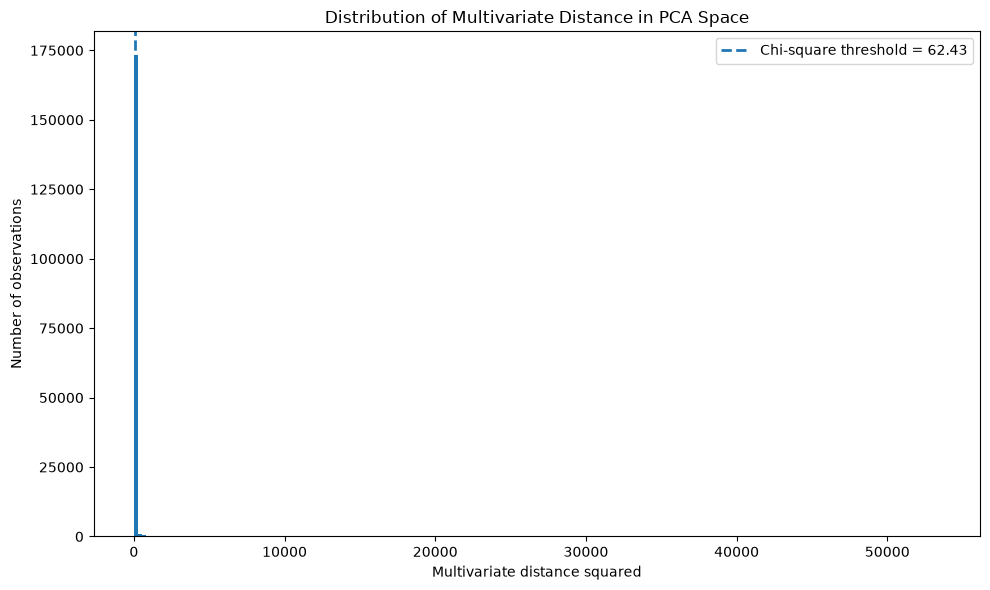

In [94]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.hist(
    mahalanobis_squared,
    bins=200
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"Chi-square threshold = {threshold:.2f}"
)

plt.xlabel("Multivariate distance squared")
plt.ylabel("Number of observations")
plt.title("Distribution of Multivariate Distance in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
distance_quantiles = np.percentile(
    mahalanobis_squared,
    [50, 75, 90, 95, 97.5, 99, 99.5, 99.9]
)

pd.DataFrame({
    "percentile": [50, 75, 90, 95, 97.5, 99, 99.5, 99.9],
    "distance_squared": distance_quantiles
})

,percentile,distance_squared
0,50.0,15.544835
1,75.0,28.741160
2,90.0,61.877554
3,95.0,85.174390
4,97.5,177.691571
5,99.0,315.963138
6,99.5,647.781378
7,99.9,2770.993445


In [96]:
# ---------------------------------------------------------
# Inspect the most extreme observations
# ---------------------------------------------------------

# Get indices of the 20 most extreme observations
top_outlier_indices = (
    np.argsort(mahalanobis_squared)[-20:][::-1]
)

print("Top 20 most extreme observation indices:")
print(top_outlier_indices)

Top 20 most extreme observation indices:
[ 99355  85756  68495  65440 113999  78578 128667 114217  72488  82938
 112818 103845 100451 121100  99846  80047 172965 135921 153524  59102]


In [97]:
print("Available variables:")
print([name for name in ["X", "X_num", "X_numeric", "df", "y", "X_pca"] if name in globals()])

Available variables:
['X', 'y', 'X_pca']


In [98]:
# ============================================================
# Inspect the most extreme multivariate observations
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Get the 20 most extreme observations
# ------------------------------------------------------------

top_n = 20

top_indices = np.argsort(mahalanobis_squared)[-top_n:][::-1]

# ------------------------------------------------------------
# 2. Extract their original features
# ------------------------------------------------------------

# X is our original feature matrix
X_original = X.copy()

# Convert to DataFrame if necessary
if not isinstance(X_original, pd.DataFrame):
    X_original = pd.DataFrame(X_original)

# Extract extreme observations
extreme_features = X_original.iloc[top_indices].copy()

# ------------------------------------------------------------
# 3. Add target and multivariate distance
# ------------------------------------------------------------

extreme_features["target"] = np.asarray(y)[top_indices]

extreme_features["multivariate_distance_squared"] = (
    mahalanobis_squared[top_indices]
)

extreme_features["original_index"] = top_indices

# Put important columns first
important_columns = [
    "original_index",
    "target",
    "multivariate_distance_squared"
]

other_columns = [
    col for col in extreme_features.columns
    if col not in important_columns
]

extreme_features = extreme_features[
    important_columns + other_columns
]

# ------------------------------------------------------------
# 4. Display
# ------------------------------------------------------------

print("=" * 70)
print("TOP 20 MULTIVARIATE EXTREME OBSERVATIONS")
print("=" * 70)

display(extreme_features)

IndexError: index 128667 is out of bounds for axis 0 with size 119341

In [99]:
print("X shape:      ", X.shape)
print("X_pca shape:  ", X_pca.shape)
print("y shape:      ", np.asarray(y).shape)

print("\nX type:")
print(type(X))

print("\ny type:")
print(type(y))

if hasattr(X, "index"):
    print("\nFirst X indices:")
    print(X.index[:10])

if hasattr(y, "index"):
    print("\nFirst y indices:")
    print(y.index[:10])

X shape:       (175341, 39)
X_pca shape:   (175341, 39)
y shape:       (119341,)

X type:
<class 'pandas.DataFrame'>

y type:
<class 'pandas.Series'>

First X indices:
RangeIndex(start=0, stop=10, step=1)

First y indices:
Index([47911, 47912, 47913, 47914, 47915, 47916, 47917, 47918, 47919, 47920], dtype='int64')


In [100]:
# ============================================================
# Check whether y's index exists in X
# ============================================================

print("X index range:")
print(X.index.min(), "to", X.index.max())

print("\ny index range:")
print(y.index.min(), "to", y.index.max())

print("\nNumber of y indices:")
print(len(y.index))

print("\nHow many y indices exist in X?")
print(y.index.isin(X.index).sum())

print("\nHow many X indices exist in y?")
print(X.index.isin(y.index).sum())

X index range:
0 to 175340

y index range:
47911 to 175340

Number of y indices:
119341

How many y indices exist in X?
119341

How many X indices exist in y?
119341


In [101]:
# ============================================================
# Align y with X / X_pca using the original row index
# ============================================================

# Create a label array aligned to X's index
y_aligned = y.reindex(X.index)

print("X shape:          ", X.shape)
print("X_pca shape:      ", X_pca.shape)
print("y_aligned shape:  ", y_aligned.shape)

print("\nMissing labels after alignment:")
print(y_aligned.isna().sum())

X shape:           (175341, 39)
X_pca shape:       (175341, 39)
y_aligned shape:   (175341,)

Missing labels after alignment:
56000


In [102]:
# ============================================================
# Check the labelled subset
# ============================================================

labelled_mask = y_aligned.notna()

print("Total observations :", len(y_aligned))
print("Labelled           :", labelled_mask.sum())
print("Unlabelled         :", y_aligned.isna().sum())

print("\nTarget distribution:")
print(y_aligned[labelled_mask].value_counts())

print("\nTarget percentages:")
print(
    y_aligned[labelled_mask]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Total observations : 175341
Labelled           : 119341
Unlabelled         : 56000

Target distribution:
PC5
 0.864020    416
 0.759821    282
-0.132717    277
 0.778518    260
-0.071775    238
            ... 
-0.520156      1
 1.392529      1
-0.353703      1
-0.500069      1
 0.157754      1
Name: count, Length: 48991, dtype: int64

Target percentages:
PC5
 0.864020    0.35
 0.759821    0.24
-0.132717    0.23
 0.778518    0.22
-0.071775    0.20
             ... 
-0.520156    0.00
 1.392529    0.00
-0.353703    0.00
-0.500069    0.00
 0.157754    0.00
Name: proportion, Length: 48991, dtype: float64


In [103]:
# Show variables that may contain the target
[name for name in globals() if any(
    word in name.lower()
    for word in ["target", "label", "attack", "class", "y"]
)]

['get_ipython',
 '__vsc_ipynb_file__',
 'dtype_comparison',
 'low_cardinality_cols',
 'zero_summary',
 'zero_by_label',
 'label_counts',
 'label_percentages',
 'target_summary',
 'attack_category_counts',
 'attack_category_percentages',
 'attack_category_summary',
 'target_columns',
 'numerical_summary',
 'proto_attack_rate',
 'proto_analysis',
 'service_analysis',
 'state_analysis',
 'numeric_label_summary',
 'mannwhitneyu',
 'attack',
 'y',
 'correlation_effect_analysis',
 'label',
 'pc_class_results',
 'loading_analysis',
 'group_analysis',
 'group_pca_analysis',
 'X_pca_array',
 'y_aligned',
 'labelled_mask']

In [105]:
# ============================================================
# Find the actual target variable
# ============================================================

import pandas as pd
import numpy as np

candidates = {}

for name, obj in globals().items():

    # Ignore internal/system variables
    if name.startswith("_"):
        continue

    # Pandas Series
    if isinstance(obj, pd.Series):
        candidates[name] = {
            "type": "Series",
            "shape": obj.shape,
            "n_unique": obj.nunique(dropna=False),
            "dtype": obj.dtype,
            "first_values": obj.head(5).tolist()
        }

    # Pandas DataFrame
    elif isinstance(obj, pd.DataFrame):
        candidates[name] = {
            "type": "DataFrame",
            "shape": obj.shape,
            "n_unique": None,
            "dtype": None,
            "first_values": list(obj.columns[:10])
        }

print("=" * 80)
print("POSSIBLE DATA VARIABLES")
print("=" * 80)

for name, info in candidates.items():
    print(
        f"{name:30s} | "
        f"{info['type']:10s} | "
        f"shape={str(info['shape']):20s} | "
        f"unique={str(info['n_unique']):8s} | "
        f"dtype={info['dtype']}"
    )

POSSIBLE DATA VARIABLES
train_df                       | DataFrame  | shape=(175341, 45)         | unique=None     | dtype=None
test_df                        | DataFrame  | shape=(82332, 45)          | unique=None     | dtype=None
schema                         | DataFrame  | shape=(45, 5)              | unique=None     | dtype=None
dtype_comparison               | DataFrame  | shape=(45, 3)              | unique=None     | dtype=None
duplicate_groups               | Series     | shape=(101040,)            | unique=2        | dtype=int64
conflicting_rows               | DataFrame  | shape=(940, 45)            | unique=None     | dtype=None
negative_counts                | Series     | shape=(41,)                | unique=1        | dtype=int64
zero_summary                   | DataFrame  | shape=(41, 2)              | unique=None     | dtype=None
zero_by_label                  | DataFrame  | shape=(41, 3)              | unique=None     | dtype=None
train_patterns                 | DataF

In [106]:
target = train_df["label"]

print("Target shape:", target.shape)
print("\nTarget values:")
print(target.unique())

print("\nTarget distribution:")
print(target.value_counts())

print("\nTarget percentages:")
print(
    target.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target shape: (175341,)

Target values:
[0 1]

Target distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Target percentages:
label
1    68.06
0    31.94
Name: proportion, dtype: float64


In [108]:
# ============================================================
# MULTIVARIATE OUTLIER ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

target = train_df["label"]

# ------------------------------------------------------------
# 1. Define threshold
# ------------------------------------------------------------

chi_square_threshold = 62.43

# ------------------------------------------------------------
# 2. Safety checks
# ------------------------------------------------------------

assert len(X) == len(X_pca) == len(target), (
    f"Shape mismatch: X={len(X)}, "
    f"X_pca={len(X_pca)}, "
    f"target={len(target)}"
)

assert len(mahalanobis_squared) == len(X), (
    f"Distance mismatch: distances={len(mahalanobis_squared)}, "
    f"X={len(X)}"
)

# ------------------------------------------------------------
# 3. Build analysis table
# ------------------------------------------------------------

outlier_analysis = pd.DataFrame({
    "original_index": X.index,
    "target": target.to_numpy(),
    "distance_squared": np.asarray(mahalanobis_squared)
})

# ------------------------------------------------------------
# 4. Identify multivariate outliers
# ------------------------------------------------------------

outlier_analysis["is_outlier"] = (
    outlier_analysis["distance_squared"]
    > chi_square_threshold
)

# ------------------------------------------------------------
# 5. Overall results
# ------------------------------------------------------------

n_outliers = outlier_analysis["is_outlier"].sum()

print("=" * 70)
print("MULTIVARIATE OUTLIER ANALYSIS")
print("=" * 70)

print(f"Observations         : {len(outlier_analysis):,}")
print(f"PCA dimensions       : {X_pca.shape[1]}")
print(f"Chi-square threshold : {chi_square_threshold:.2f}")
print(f"Outliers detected    : {n_outliers:,}")
print(
    f"Outlier percentage   : "
    f"{n_outliers / len(outlier_analysis) * 100:.2f}%"
)

# ------------------------------------------------------------
# 6. Outlier counts by class
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OUTLIERS BY CLASS")
print("=" * 70)

outlier_by_class = pd.crosstab(
    outlier_analysis["target"],
    outlier_analysis["is_outlier"]
)

display(outlier_by_class)

# ------------------------------------------------------------
# 7. Outlier rate WITHIN each class
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OUTLIER RATE WITHIN EACH CLASS")
print("=" * 70)

outlier_rate_by_class = (
    outlier_analysis
    .groupby("target")["is_outlier"]
    .mean()
    .mul(100)
    .round(2)
)

display(outlier_rate_by_class)

# ------------------------------------------------------------
# 8. Class composition OF the outlier population
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS COMPOSITION OF OUTLIERS")
print("=" * 70)

outlier_class_composition = (
    outlier_analysis.loc[
        outlier_analysis["is_outlier"],
        "target"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(outlier_class_composition)

# ------------------------------------------------------------
# 9. Top 20 most unusual observations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 20 MOST UNUSUAL OBSERVATIONS")
print("=" * 70)

top_extreme = (
    outlier_analysis
    .sort_values(
        "distance_squared",
        ascending=False
    )
    .head(20)
)

display(top_extreme)

MULTIVARIATE OUTLIER ANALYSIS
Observations         : 175,341
PCA dimensions       : 39
Chi-square threshold : 62.43
Outliers detected    : 17,336
Outlier percentage   : 9.89%

OUTLIERS BY CLASS


is_outlier,False,True
target,,
0,46487,9513
1,111518,7823



OUTLIER RATE WITHIN EACH CLASS


target
0    16.99
1     6.56
Name: is_outlier, dtype: float64


CLASS COMPOSITION OF OUTLIERS


target
0    54.87
1    45.13
Name: proportion, dtype: float64


TOP 20 MOST UNUSUAL OBSERVATIONS


,original_index,target,distance_squared,is_outlier
99355,99355,1,53478.836962,True
85756,85756,1,48023.320631,True
68495,68495,1,43382.726429,True
65440,65440,1,35612.802654,True
113999,113999,1,35279.238224,True
78578,78578,1,35146.837642,True
128667,128667,1,35129.506127,True
114217,114217,1,35122.092098,True
72488,72488,1,18441.266381,True
82938,82938,1,18045.696690,True


In [109]:
# ============================================================
# COMPARE MULTIVARIATE OUTLIERS WITHIN EACH CLASS
# ============================================================

# Attach outlier information to the original numerical features
feature_outlier_df = X.copy()

feature_outlier_df["target"] = target.to_numpy()
feature_outlier_df["is_outlier"] = (
    outlier_analysis["is_outlier"].to_numpy()
)

# ------------------------------------------------------------
# Create four groups
# ------------------------------------------------------------

normal_regular = feature_outlier_df[
    (feature_outlier_df["target"] == 0) &
    (~feature_outlier_df["is_outlier"])
]

normal_outlier = feature_outlier_df[
    (feature_outlier_df["target"] == 0) &
    (feature_outlier_df["is_outlier"])
]

attack_regular = feature_outlier_df[
    (feature_outlier_df["target"] == 1) &
    (~feature_outlier_df["is_outlier"])
]

attack_outlier = feature_outlier_df[
    (feature_outlier_df["target"] == 1) &
    (feature_outlier_df["is_outlier"])
]

print("Group sizes")
print("=" * 60)

print(f"Normal regular : {len(normal_regular):,}")
print(f"Normal outlier : {len(normal_outlier):,}")
print(f"Attack regular : {len(attack_regular):,}")
print(f"Attack outlier : {len(attack_outlier):,}")

Group sizes
Normal regular : 46,487
Normal outlier : 9,513
Attack regular : 111,518
Attack outlier : 7,823


In [110]:
# ============================================================
# OUTLIER PROFILING — ORIGINAL FEATURES
# ============================================================

import pandas as pd
import numpy as np

# Original numerical features only
feature_cols = X.columns.tolist()

groups = {
    "Normal_Regular": normal_regular[feature_cols],
    "Normal_Outlier": normal_outlier[feature_cols],
    "Attack_Regular": attack_regular[feature_cols],
    "Attack_Outlier": attack_outlier[feature_cols],
}

# ------------------------------------------------------------
# Calculate medians for each group
# ------------------------------------------------------------

median_table = pd.DataFrame({
    group_name: data.median()
    for group_name, data in groups.items()
})

# ------------------------------------------------------------
# Calculate mean for each group
# ------------------------------------------------------------

mean_table = pd.DataFrame({
    group_name: data.mean()
    for group_name, data in groups.items()
})

print("=" * 80)
print("MEDIAN OF ORIGINAL FEATURES BY GROUP")
print("=" * 80)

display(median_table)

print("=" * 80)
print("MEAN OF ORIGINAL FEATURES BY GROUP")
print("=" * 80)

display(mean_table)

MEDIAN OF ORIGINAL FEATURES BY GROUP


,Normal_Regular,Normal_Outlier,Attack_Regular,Attack_Outlier
dur,3.616200e-02,3.762880e-01,9.000000e-06,2.564251e+00
spkts,1.200000e+01,8.000000e+00,2.000000e+00,2.200000e+01
dpkts,1.200000e+01,4.000000e+00,0.000000e+00,1.000000e+01
sbytes,1.506000e+03,9.780000e+02,2.000000e+02,1.488000e+03
dbytes,1.276000e+03,2.680000e+02,0.000000e+00,6.820000e+02
rate,1.799318e+03,3.767142e+01,1.111111e+05,2.142765e+01
sttl,3.100000e+01,3.100000e+01,2.540000e+02,2.540000e+02
dttl,2.900000e+01,2.900000e+01,0.000000e+00,2.520000e+02
sload,5.122807e+05,1.241125e+04,5.700000e+07,5.760806e+03
dload,5.987748e+05,8.084853e+02,0.000000e+00,2.767537e+03


MEAN OF ORIGINAL FEATURES BY GROUP


,Normal_Regular,Normal_Outlier,Attack_Regular,Attack_Outlier
dur,3.575022e-01,4.240798e+00,5.471666e-01,1.538741e+01
spkts,2.230066e+01,7.189488e+01,7.856005e+00,1.230314e+02
dpkts,2.214288e+01,1.158283e+02,4.704120e+00,8.568605e+01
sbytes,3.857129e+03,5.320404e+03,3.445083e+03,1.197438e+05
dbytes,1.190155e+04,1.246192e+05,2.029408e+03,8.341634e+04
rate,1.199652e+04,2.260898e+04,1.397096e+05,4.802733e+04
sttl,7.816624e+01,6.215295e+01,2.318800e+02,1.787270e+02
dttl,6.876030e+01,4.236445e+01,8.161900e+01,1.607261e+02
sload,1.832490e+07,4.685059e+07,9.186025e+07,1.710179e+08
dload,2.239127e+06,1.202025e+06,1.354877e+04,8.356991e+04


In [113]:
print("outlier_df shape:", outlier_df.shape)
print("\nColumns:")
print(outlier_df.columns.tolist())

print("\nIndex:")
print(outlier_df.index)

print("\nFirst 5 rows:")
display(outlier_df.head())

outlier_df shape: (175341, 3)

Columns:
['observation_index', 'multivariate_distance_squared', 'is_outlier']

Index:
RangeIndex(start=0, stop=175341, step=1)

First 5 rows:


,observation_index,multivariate_distance_squared,is_outlier
0,99355,53478.836962,True
1,85756,48023.320631,True
2,68495,43382.726429,True
3,65440,35612.802654,True
4,113999,35279.238224,True


In [114]:
import pandas as pd
import numpy as np

# ============================================================
# FINAL: INVESTIGATE MULTIVARIATE OUTLIERS
# ============================================================

# 1. Get the 20 most extreme observations
top_outliers = (
    outlier_df
    .sort_values(
        "multivariate_distance_squared",
        ascending=False
    )
    .head(20)
    .copy()
)

print("=" * 80)
print("TOP 20 MOST EXTREME OBSERVATIONS")
print("=" * 80)

display(top_outliers)


# ============================================================
# 2. Get their original rows
# ============================================================

top_indices = top_outliers["observation_index"].astype(int)

extreme_rows = train_df.iloc[top_indices].copy()


# ============================================================
# 3. Add outlier information
# ============================================================

distance_lookup = (
    outlier_df
    .set_index("observation_index")
    ["multivariate_distance_squared"]
)

outlier_lookup = (
    outlier_df
    .set_index("observation_index")
    ["is_outlier"]
)

extreme_rows["multivariate_distance_squared"] = (
    distance_lookup.loc[top_indices].to_numpy()
)

extreme_rows["is_multivariate_outlier"] = (
    outlier_lookup.loc[top_indices].to_numpy()
)


# ============================================================
# 4. Show target / attack information
# ============================================================

display_columns = [
    "label",
    "attack_cat",
    "proto",
    "service",
    "state",
    "multivariate_distance_squared",
    "is_multivariate_outlier"
]

display_columns = [
    col for col in display_columns
    if col in extreme_rows.columns
]

print("\n" + "=" * 80)
print("EXTREME OBSERVATIONS WITH LABEL INFORMATION")
print("=" * 80)

display(extreme_rows[display_columns])


# ============================================================
# 5. Target distribution among the 20 extreme observations
# ============================================================

if "label" in extreme_rows.columns:

    print("\n" + "=" * 80)
    print("TARGET DISTRIBUTION")
    print("=" * 80)

    print(
        extreme_rows["label"]
        .value_counts()
    )

    print("\nPercentage:")

    print(
        extreme_rows["label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


# ============================================================
# 6. Attack category distribution
# ============================================================

if "attack_cat" in extreme_rows.columns:

    print("\n" + "=" * 80)
    print("ATTACK CATEGORY DISTRIBUTION")
    print("=" * 80)

    display(
        extreme_rows["attack_cat"]
        .value_counts(dropna=False)
    )


# ============================================================
# 7. Compare extreme observations against the whole dataset
# ============================================================

numeric_features = train_df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target from feature comparison
numeric_features = [
    col for col in numeric_features
    if col not in ["label"]
]

overall_median = train_df[numeric_features].median()

extreme_median = extreme_rows[numeric_features].median()

feature_comparison = pd.DataFrame({
    "overall_median": overall_median,
    "extreme_median": extreme_median
})

feature_comparison["absolute_difference"] = (
    feature_comparison["extreme_median"]
    - feature_comparison["overall_median"]
).abs()

feature_comparison = (
    feature_comparison
    .sort_values(
        "absolute_difference",
        ascending=False
    )
)

print("\n" + "=" * 80)
print("FEATURES MOST DIFFERENT IN EXTREME OBSERVATIONS")
print("=" * 80)

display(feature_comparison.head(20))

TOP 20 MOST EXTREME OBSERVATIONS


,observation_index,multivariate_distance_squared,is_outlier
0,99355,53478.836962,True
1,85756,48023.320631,True
2,68495,43382.726429,True
3,65440,35612.802654,True
4,113999,35279.238224,True
5,78578,35146.837642,True
6,128667,35129.506127,True
7,114217,35122.092098,True
8,72488,18441.266381,True
9,82938,18045.696690,True



EXTREME OBSERVATIONS WITH LABEL INFORMATION


,label,attack_cat,proto,service,state,multivariate_distance_squared,is_multivariate_outlier
99355,1,Exploits,tcp,http,FIN,53478.836962,True
85756,1,Exploits,tcp,http,FIN,48023.320631,True
68495,1,Exploits,tcp,http,FIN,43382.726429,True
65440,1,Exploits,udp,dns,CON,35612.802654,True
113999,1,Exploits,udp,dns,CON,35279.238224,True
78578,1,Exploits,udp,dns,CON,35146.837642,True
128667,1,Exploits,udp,dns,CON,35129.506127,True
114217,1,Exploits,udp,dns,CON,35122.092098,True
72488,1,DoS,tcp,pop3,FIN,18441.266381,True
82938,1,DoS,tcp,pop3,CON,18045.696690,True



TARGET DISTRIBUTION
label
1    20
Name: count, dtype: int64

Percentage:
label
1    100.0
Name: proportion, dtype: float64

ATTACK CATEGORY DISTRIBUTION


attack_cat
Exploits    12
DoS          7
Generic      1
Name: count, dtype: int64


FEATURES MOST DIFFERENT IN EXTREME OBSERVATIONS


,overall_median,extreme_median,absolute_difference
dtcpb,0.000000,1.302149e+09,1.302149e+09
stcpb,0.000000,3.149026e+08,3.149026e+08
dbytes,164.000000,4.259520e+06,4.259356e+06
sload,879674.750000,5.725872e+03,8.739489e+05
dload,1447.022705,6.115608e+05,6.101138e+05
sbytes,430.000000,4.296900e+04,4.253900e+04
id,87671.000000,1.001495e+05,1.247850e+04
rate,3225.806520,9.043066e+01,3.135376e+03
dpkts,2.000000,3.121000e+03,3.119000e+03
sjit,0.000000,1.636944e+03,1.636944e+03


In [115]:
# ============================================================
# FINAL EDA AUDIT — STEP 1
# IDENTIFY ID / TARGET / POSSIBLE LEAKAGE COLUMNS
# ============================================================

print("=" * 80)
print("EDA → MODELING FEATURE AUDIT")
print("=" * 80)

print("\nDataset shape:")
print(train_df.shape)

print("\nAll columns:")
print(train_df.columns.tolist())


# ------------------------------------------------------------
# 1. Target columns
# ------------------------------------------------------------

target_candidates = [
    col for col in ["label", "attack_cat"]
    if col in train_df.columns
]

print("\n" + "=" * 80)
print("TARGET COLUMNS")
print("=" * 80)

print(target_candidates)


# ------------------------------------------------------------
# 2. Identifier-like columns
# ------------------------------------------------------------

identifier_candidates = []

for col in train_df.columns:

    col_lower = col.lower()

    if (
        col_lower == "id"
        or col_lower.endswith("_id")
        or col_lower.startswith("id_")
    ):
        identifier_candidates.append(col)

print("\n" + "=" * 80)
print("IDENTIFIER-LIKE COLUMNS")
print("=" * 80)

print(identifier_candidates)


# ------------------------------------------------------------
# 3. Constant columns
# ------------------------------------------------------------

constant_columns = [
    col
    for col in train_df.columns
    if train_df[col].nunique(dropna=False) <= 1
]

print("\n" + "=" * 80)
print("CONSTANT COLUMNS")
print("=" * 80)

print(constant_columns)


# ------------------------------------------------------------
# 4. Extremely high-cardinality columns
# ------------------------------------------------------------

high_cardinality = []

n_rows = len(train_df)

for col in train_df.columns:

    unique_count = train_df[col].nunique(dropna=False)

    if unique_count / n_rows > 0.95:
        high_cardinality.append(
            (col, unique_count, unique_count / n_rows)
        )

high_cardinality_df = pd.DataFrame(
    high_cardinality,
    columns=[
        "feature",
        "unique_values",
        "unique_ratio"
    ]
)

print("\n" + "=" * 80)
print("HIGH-CARDINALITY COLUMNS")
print("=" * 80)

display(high_cardinality_df)


# ------------------------------------------------------------
# 5. Candidate modeling features
# ------------------------------------------------------------

excluded_columns = set(
    target_candidates
    + identifier_candidates
    + constant_columns
)

candidate_features = [
    col
    for col in train_df.columns
    if col not in excluded_columns
]

print("\n" + "=" * 80)
print("INITIAL MODELING FEATURE CANDIDATES")
print("=" * 80)

print("Number of candidate features:", len(candidate_features))

print(candidate_features)


# ------------------------------------------------------------
# 6. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print("Total columns       :", len(train_df.columns))
print("Target columns      :", target_candidates)
print("Identifier columns  :", identifier_candidates)
print("Constant columns    :", constant_columns)
print("Candidate features  :", len(candidate_features))

EDA → MODELING FEATURE AUDIT

Dataset shape:
(175341, 45)

All columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

TARGET COLUMNS
['label', 'attack_cat']

IDENTIFIER-LIKE COLUMNS
['id']

CONSTANT COLUMNS
[]

HIGH-CARDINALITY COLUMNS


,feature,unique_values,unique_ratio
0,id,175341,1.0



INITIAL MODELING FEATURE CANDIDATES
Number of candidate features: 42
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

SUMMARY
Total columns       : 45
Target columns      : ['label', 'attack_cat']
Identifier columns  : ['id']
Constant columns    : []
Candidate features  : 42


In [116]:
# ============================================================
# EDA → MODELING AUDIT — STEP 2
# TARGET LEAKAGE CHECK
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("TARGET LEAKAGE AUDIT")
print("=" * 80)


# ------------------------------------------------------------
# 1. Check exact feature == label relationships
# ------------------------------------------------------------

y_binary = train_df["label"]

exact_matches = []

for feature in candidate_features:

    if train_df[feature].nunique(dropna=False) <= 20:

        # Only compare directly when values are numeric/binary-like
        try:
            match = (
                train_df[feature].astype(float).to_numpy()
                == y_binary.astype(float).to_numpy()
            ).mean()

            exact_matches.append(
                (feature, match)
            )

        except (ValueError, TypeError):
            pass


exact_match_df = pd.DataFrame(
    exact_matches,
    columns=["feature", "fraction_equal_to_label"]
).sort_values(
    "fraction_equal_to_label",
    ascending=False
)

print("\n" + "=" * 80)
print("FEATURES MOST SIMILAR TO LABEL")
print("=" * 80)

display(exact_match_df.head(15))


# ------------------------------------------------------------
# 2. Numerical features: attack vs normal separation
# ------------------------------------------------------------

numeric_features = train_df[
    candidate_features
].select_dtypes(
    include=np.number
).columns.tolist()

numeric_leakage = []

for feature in numeric_features:

    normal_values = train_df.loc[
        train_df["label"] == 0,
        feature
    ]

    attack_values = train_df.loc[
        train_df["label"] == 1,
        feature
    ]

    normal_median = normal_values.median()
    attack_median = attack_values.median()

    normal_mean = normal_values.mean()
    attack_mean = attack_values.mean()

    numeric_leakage.append({
        "feature": feature,
        "normal_median": normal_median,
        "attack_median": attack_median,
        "normal_mean": normal_mean,
        "attack_mean": attack_mean
    })

numeric_leakage_df = pd.DataFrame(
    numeric_leakage
)

print("\n" + "=" * 80)
print("NUMERICAL FEATURE TARGET SEPARATION")
print("=" * 80)

display(
    numeric_leakage_df.head(20)
)


# ------------------------------------------------------------
# 3. Categorical features: target purity
# ------------------------------------------------------------

categorical_features = train_df[
    candidate_features
].select_dtypes(
    exclude=np.number
).columns.tolist()

print("\n" + "=" * 80)
print("CATEGORICAL FEATURES")
print("=" * 80)

print(categorical_features)


for feature in categorical_features:

    print("\n" + "-" * 80)
    print(f"FEATURE: {feature}")
    print("-" * 80)

    analysis = (
        train_df
        .groupby(feature)["label"]
        .agg(
            count="count",
            attack_rate="mean"
        )
        .sort_values(
            "attack_rate",
            ascending=False
        )
    )

    analysis["attack_rate"] = (
        analysis["attack_rate"] * 100
    ).round(2)

    display(analysis.head(20))


# ------------------------------------------------------------
# 4. Check attack_cat separately
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ATTACK_CAT — NOT A MODEL FEATURE")
print("=" * 80)

print(
    train_df.groupby("attack_cat")["label"]
    .agg(
        count="count",
        attack_rate="mean"
    )
)


# ------------------------------------------------------------
# 5. Final leakage reminder
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LEAKAGE AUDIT RULE")
print("=" * 80)

print("""
For the binary model:

TARGET:
    label

EXCLUDE:
    id
    attack_cat

INITIAL FEATURES:
    candidate_features

A feature being strongly associated with label
does NOT automatically mean it is leakage.

It may simply be a genuinely useful predictive feature.
""")

TARGET LEAKAGE AUDIT

FEATURES MOST SIMILAR TO LABEL


,feature,fraction_equal_to_label
5,ct_state_ttl,0.459430
4,trans_depth,0.361901
8,ct_flw_http_mthd,0.357623
6,is_ftp_login,0.323079
7,ct_ftp_cmd,0.323079
9,is_sm_ips_ports,0.303626
3,dwin,0.101157
2,swin,0.096264
1,dttl,0.038474
0,sttl,0.016305



NUMERICAL FEATURE TARGET SEPARATION


,feature,normal_median,attack_median,normal_mean,attack_mean
0,dur,3.860250e-02,9.000000e-06,1.017177e+00,1.519969e+00
1,spkts,1.200000e+01,2.000000e+00,3.072548e+01,1.540595e+01
2,dpkts,1.000000e+01,0.000000e+00,3.805770e+01,1.001262e+01
3,sbytes,1.470000e+03,2.000000e+02,4.105703e+03,1.106866e+04
4,dbytes,1.112000e+03,0.000000e+00,3.104946e+04,7.364456e+03
5,rate,1.382257e+03,1.111111e+05,1.379931e+04,1.336997e+05
6,sttl,3.100000e+01,2.540000e+02,7.544598e+01,2.283957e+02
7,dttl,2.900000e+01,0.000000e+00,6.427630e+01,8.680460e+01
8,sload,4.313277e+05,5.066666e+07,2.317070e+07,9.704916e+07
9,dload,3.361206e+05,0.000000e+00,2.062949e+06,1.813877e+04



CATEGORICAL FEATURES
['proto', 'service', 'state']

--------------------------------------------------------------------------------
FEATURE: proto
--------------------------------------------------------------------------------


...


--------------------------------------------------------------------------------
FEATURE: service
--------------------------------------------------------------------------------


,count,attack_rate
service,,
dhcp,94,100.00
ssl,56,100.00
irc,25,100.00
pop3,1105,99.64
snmp,80,98.75
dns,47294,84.16
radius,12,83.33
http,18724,71.44
smtp,5058,68.78



--------------------------------------------------------------------------------
FEATURE: state
--------------------------------------------------------------------------------


,count,attack_rate
state,,
INT,82275,93.05
REQ,1991,53.54
FIN,77825,52.23
RST,83,14.46
CON,13152,8.01
PAR,1,0.00
ECO,12,0.00
URN,1,0.00
no,1,0.00



ATTACK_CAT — NOT A MODEL FEATURE
                count  attack_rate
attack_cat                        
Analysis         2000          1.0
Backdoor         1746          1.0
DoS             12264          1.0
Exploits        33393          1.0
Fuzzers         18184          1.0
Generic         40000          1.0
Normal          56000          0.0
Reconnaissance  10491          1.0
Shellcode        1133          1.0
Worms             130          1.0

LEAKAGE AUDIT RULE

For the binary model:

TARGET:
    label

EXCLUDE:
    id
    attack_cat

INITIAL FEATURES:
    candidate_features

A feature being strongly associated with label
does NOT automatically mean it is leakage.

It may simply be a genuinely useful predictive feature.



In [117]:
# ============================================================
# MODELING DATASET
# ============================================================

# Features
model_features = [
    col
    for col in train_df.columns
    if col not in ["id", "attack_cat", "label"]
]

# X = predictors
X_model = train_df[model_features].copy()

# y = binary target
y_model = train_df["label"].copy()

print("=" * 70)
print("MODELING DATASET")
print("=" * 70)

print("X shape:", X_model.shape)
print("y shape:", y_model.shape)

print("\nFeatures:")
print(model_features)

print("\nNumerical features:",
      X_model.select_dtypes(include=np.number).shape[1])

print("Categorical features:",
      X_model.select_dtypes(exclude=np.number).shape[1])

print("\nTarget distribution:")
print(y_model.value_counts())

print("\nTarget percentages:")
print(
    y_model.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

MODELING DATASET
X shape: (175341, 42)
y shape: (175341,)

Features:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

Numerical features: 39
Categorical features: 3

Target distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Target percentages:
label
1    68.06
0    31.94
Name: proportion, dtype: float64
